In [ ]:
#FOREX rate USD/CNY
import requests
import pandas as pd
from io import StringIO
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Scikit-learn preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB

# Advanced implementations
import xgboost as xgb
import lightgbm as lgb



print("✓ All libraries imported successfully!")

url = 'https://www.alphavantage.co/query?function=FX_DAILY&from_symbol=USD&to_symbol=CNY&outputsize=full&apikey=EYRFF67Q8LIYEZ1N&datatype=csv'
r = requests.get(url)
data_string = r.text
data = StringIO(data_string)
#transform to panda dataframe
df = pd.read_csv(data)
df_removed=df.drop(columns=['open','high','low'])
df_FOREX,df_fx=df_removed.rename(columns={'timestamp': 'Date', 'close': 'USD_rate_CNY'})
 # Filter rows with 'Date' >= 2014-12-31
df_FOREX = df_FOREX[df_FOREX['Date'] > '2013-12-31'].drop([0])
df_FOREX=df_FOREX[df_FOREX['Date'] < '2025-01-01']

#df_FOREX.to_excel('FOREX_data.xlsx', index=False)
print(df)
print(df.dtypes)
print(df_FOREX)

✓ All libraries imported successfully!


TypeError: string indices must be integers, not 'str'

In [ ]:
# 10-year Treasury yield US
url1='https://www.alphavantage.co/query?function=TREASURY_YIELD&interval=daily&maturity=10year&apikey=EYRFF67Q8LIYEZ1N&datatype=csv'
r_10Y = requests.get(url1)

# Check if the request was successful
if r_10Y.status_code == 200:
    # Convert the response content into a CSV-like object
    csv_data = StringIO(r_10Y.text)  # Extract text from the response

    # Read the CSV data into a DataFrame
    df = pd.read_csv(csv_data)

    # Rename the columns
    df_10Y = df.rename(columns={'timestamp': 'Date', 'value': '10YTreasury_US'})
     # Convert 'Date' column to datetime
    df_10Y['Date'] = pd.to_datetime(df_10Y['Date'])

    # Filter rows with 'Date' >= 2014-12-31
    df_10Y = df_10Y[df_10Y['Date'] > '2013-12-31']
    df_10Y = df_10Y[df_10Y['Date'] < '2025-01-01']

    df_10Y = df_10Y.set_index('Date')
    df_10Y_US = df_10Y.resample('D').ffill()
    df_10Y_US1=df_10Y_US.sort_values(by='Date', ascending=False).reset_index()


    #rename column close to new name 10YTreasury_US
    df_10Y_US1=df_10Y_US1.rename(columns={'close': '10YTreasury_US'})
     # drop rows with 'Date' >= 2024-12-31
    df_10Y_US = df_10Y_US1.drop([0,1])
    # Print the DataFrame
    #df_10Y_US.to_excel(' df_10Y_US2.xlsx', index=False)
    print(df_10Y_US)
else:
    print(f"Failed to fetch data. HTTP Status Code: {r_10Y.status_code}")

print(df)
print(df.dtypes)

           Date 10YTreasury_US
2    2024-12-29           4.62
3    2024-12-28           4.62
4    2024-12-27           4.62
5    2024-12-26           4.58
6    2024-12-25              .
...         ...            ...
4013 2014-01-05           3.01
4014 2014-01-04           3.01
4015 2014-01-03           3.01
4016 2014-01-02           3.00
4017 2014-01-01              .

[4016 rows x 2 columns]
        timestamp value
0      2025-12-11  4.14
1      2025-12-10  4.13
2      2025-12-09  4.18
3      2025-12-08  4.17
4      2025-12-05  4.14
...           ...   ...
16678  1962-01-08  4.03
16679  1962-01-05  4.02
16680  1962-01-04  3.99
16681  1962-01-03  4.03
16682  1962-01-02  4.06

[16683 rows x 2 columns]
timestamp    object
value        object
dtype: object


In [ ]:
#Data Cleaning China_10YBond.xlsx
import pandas as pd

import pandas as pd

# Path to your Excel file
file_path = '/content/China_10YBond.xlsx'

# Read all worksheets
sheets = pd.read_excel(file_path, sheet_name=None)

# Renaming columns and filtering for 'Date' and '10Y'
sheets_renamed = {sheet_name: df.rename(columns={'日期': 'Date', '10年': '10Y_China'}).loc[:, ['Date', '10Y_China']] for sheet_name, df in sheets.items()}

# Combine all sheets into a single DataFrame
combined_df = pd.concat(sheets_renamed.values(), ignore_index=True)

combined_df ['Date'] = pd.to_datetime(combined_df ['Date'])

df_10Y_China1= combined_df.sort_values(by='Date').reset_index(drop=True)

# Filter rows with 'Date' >= 2014-12-31
df_10Y_China  = df_10Y_China1[df_10Y_China1['Date'] > '2013-12-31'].sort_values(by='Date',ascending=False).reset_index()
# Display the combined DataFrame
#df_10Y_China.to_excel(' df_10Y_China .xlsx', index=False)
print(df_10Y_China )



      index       Date  10Y_China
0      2750 2024-12-27     1.6929
1      2749 2024-12-26     1.7122
2      2748 2024-12-25     1.7365
3      2747 2024-12-24     1.7166
4      2746 2024-12-23     1.7019
...     ...        ...        ...
2746      4 2014-01-08     4.5919
2747      3 2014-01-07     4.6420
2748      2 2014-01-06     4.6569
2749      1 2014-01-03     4.6415
2750      0 2014-01-02     4.6018

[2751 rows x 3 columns]


In [ ]:
#CPI US
fileUrl='/content/CPI_US.xlsx'
df_cpi_us =pd.read_excel(fileUrl)
df_cpi_us=df_cpi_us.sort_values(by='Date',ascending=False).reset_index().drop(columns=['index'])
#df_cpi_us.to_excel('df_cpi_us.xlsx', index=False)
print(df_cpi_us)



# CPI US from website Alpha Vantage
'''url=url = 'https://www.alphavantage.co/query?function=CPI&interval=monthly&apikey=EYRFF67Q8LIYEZ1N&datatype=csv'
r = requests.get(url)
data_string = r.text
data = StringIO(data_string)
#transform to panda dataframe
df = pd.read_csv(data)
print(df)
print(df.dtypes)'''

          Date      CPI_US
0   2024-11-01  144.684725
1   2024-10-01  144.763145
2   2024-09-01  144.596674
3   2024-08-01  144.365081
4   2024-07-01  144.247680
..         ...         ...
126 2014-05-01  109.100665
127 2014-04-01  108.720945
128 2014-03-01  108.363696
129 2014-02-01  107.670295
130 2014-01-01  107.273607

[131 rows x 2 columns]


"url=url = 'https://www.alphavantage.co/query?function=CPI&interval=monthly&apikey=EYRFF67Q8LIYEZ1N&datatype=csv'\nr = requests.get(url)\ndata_string = r.text\ndata = StringIO(data_string)\n#transform to panda dataframe\ndf = pd.read_csv(data)\nprint(df)\nprint(df.dtypes)"

In [ ]:
#CPI China
fileUrl_China='/content/CPI_China.xlsx'
df_cpi_china =pd.read_excel(fileUrl_China)
df_cpi_china=df_cpi_china.sort_values(by='Date',ascending=False).reset_index().drop(columns=['index'])
#df_cpi_china.to_excel('df_cpi_china .xlsx', index=False)
print(df_cpi_china)

          Date   CPI_China
0   2024-12-01  132.036865
1   2024-11-01  132.036865
2   2024-10-01  132.806012
3   2024-09-01  133.062394
4   2024-08-01  133.062394
..         ...         ...
127 2014-05-01  112.968447
128 2014-04-01  112.853524
129 2014-03-01  113.313217
130 2014-02-01  113.887821
131 2014-01-01  113.313217

[132 rows x 2 columns]


In [ ]:
#interest rate US
url = 'https://www.alphavantage.co/query?function=FEDERAL_FUNDS_RATE&interval=monthly&apikey=EYRFF67Q8LIYEZ1N&datatype=csv'
r = requests.get(url)
# Convert the response content into a CSV-like object
csv_data = StringIO(r.text)

# Read the CSV data into a DataFrame
df = pd.read_csv(csv_data)

 # Rename the columns
df_interest_US = df.rename(columns={'timestamp': 'Date', 'value': 'interest_US'})
# Convert 'Date' column to datetime
df_interest_US ['Date'] = pd.to_datetime(df_interest_US ['Date'])

# Filter rows with 'Date' >= 2014-12-31
df_interest_US  = df_interest_US[df_interest_US['Date'] > '2013-12-31']

# Print the DataFrame
expanded_df = (
    df_interest_US.set_index('Date')  # Set 'Date' as index
    .resample('D')                   # Resample daily
    .ffill()                         # Fill NaN values with the last valid value
    .reset_index()                   # Reset index to get 'Date' back as a column
)
df_interest_US= expanded_df.sort_values(by='Date', ascending=False).reset_index()
df_interest_US=df_interest_US.drop(columns=['index'])
#df_interest_US.to_excel('df_interest_US .xlsx', index=False)
print(df_interest_US )
print(df)
print(df.dtypes)

           Date  interest_US
0    2025-11-01         3.88
1    2025-10-31         4.09
2    2025-10-30         4.09
3    2025-10-29         4.09
4    2025-10-28         4.09
...         ...          ...
4318 2014-01-05         0.07
4319 2014-01-04         0.07
4320 2014-01-03         0.07
4321 2014-01-02         0.07
4322 2014-01-01         0.07

[4323 rows x 2 columns]
      timestamp  value
0    2025-11-01   3.88
1    2025-10-01   4.09
2    2025-09-01   4.22
3    2025-08-01   4.33
4    2025-07-01   4.33
..          ...    ...
852  1954-11-01   0.83
853  1954-10-01   0.85
854  1954-09-01   1.07
855  1954-08-01   1.22
856  1954-07-01   0.80

[857 rows x 2 columns]
timestamp     object
value        float64
dtype: object


In [ ]:
#interest China  interest_China
file_path = '/content/China_1YLPR.xlsx'

# Read all worksheets
sheets_interest = pd.read_excel(file_path,sheet_name=None)
# Combine all sheets into a single DataFrame
combined_df_interestChina = pd.concat(sheets_interest.values(), ignore_index=True)
combined_df_interestChina =combined_df_interestChina.drop(columns=['5Y'])
combined_df_interestChina =combined_df_interestChina.drop(index=[1492,1493])

nan_date_rows = combined_df_interestChina[combined_df_interestChina['Date'].isna()]
combined_df_interestChina=combined_df_interestChina.drop(index=nan_date_rows.index)

# Convert the '1Y' column to numeric, coercing errors to NaN
combined_df_interestChina['1Y'] = pd.to_numeric(combined_df_interestChina['1Y'], errors='coerce')

# Drop rows where '1Y' is NaN (i.e., non-numeric values)
combined_df_interestChina = combined_df_interestChina.dropna(subset=['1Y'])

# Convert the Date column to datetime and format it
combined_df_interestChina['Date'] = pd.to_datetime(combined_df_interestChina['Date'], format='%d %b %Y')
combined_df_interestChina['Date'] = combined_df_interestChina['Date'].dt.strftime('%Y-%m-%d')
combined_df_interestChina=combined_df_interestChina.sort_values(by='Date',ascending=False).reset_index()
combined_df_interestChina=combined_df_interestChina.drop(columns=['index'])
df_interestChina=combined_df_interestChina.rename(columns={'1Y': 'interest_China'})
#df_interestChina.to_excel('df_interestChina .xlsx', index=False)
print(df_interestChina)

            Date  interest_China
0     2024-12-20            3.10
1     2024-11-20            3.10
2     2024-10-21            3.10
3     2024-09-20            3.35
4     2024-08-20            3.35
...          ...             ...
1467  2014-01-08            5.73
1468  2014-01-07            5.73
1469  2014-01-06            5.73
1470  2014-01-03            5.73
1471  2014-01-02            5.73

[1472 rows x 2 columns]


In [ ]:
import numpy as np
#create a dataframe with date from 2014-01-01 to 2024-12-31
import pandas as pd
start_date = '2014-01-01'
end_date = '2024-12-31'
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
df_date = pd.DataFrame({'Date': date_range})

#print(df_date)
#merge df_FOREX and df_date
df_date['Date'] = pd.to_datetime(df_date['Date'])
df_FOREX['Date'] = pd.to_datetime(df_FOREX['Date'])
df_interestChina['Date'] = pd.to_datetime(df_interestChina['Date'])

# Now perform the merge
df_whole_frame = pd.merge(df_date, df_FOREX, on='Date', how='left')
#fill NaN by using forward
df_whole_frame['USD_rate_CNY'] = df_whole_frame['USD_rate_CNY'].fillna(method='ffill')

#merge df_10Y_US
df_whole_frame=pd.merge(df_whole_frame, df_10Y_US, on='Date', how='left')
#clean the . of 10YTreasury_US
filtered_df = df_whole_frame[df_whole_frame['10YTreasury_US'] == '.']
df_whole_frame.loc[filtered_df.index, '10YTreasury_US'] = np.nan
#fill NaN by using forward
df_whole_frame['10YTreasury_US'] = df_whole_frame['10YTreasury_US'].fillna(method='ffill')
df_whole_frame.at[0, '10YTreasury_US'] = df_whole_frame.at[1, '10YTreasury_US']
#convert 10YTreasury_US to interger
df_whole_frame['10YTreasury_US'] = df_whole_frame['10YTreasury_US'].astype(float)


#merge df_cpi_us
df_whole_frame=pd.merge(df_whole_frame, df_cpi_us, on='Date', how='left')
#fill NaN by using forward
df_whole_frame['CPI_US'] = df_whole_frame['CPI_US'].fillna(method='ffill')

#merge df_cpi_china
df_whole_frame=pd.merge(df_whole_frame, df_cpi_china, on='Date', how='left')
#fill NaN by using forward
df_whole_frame['CPI_China'] = df_whole_frame['CPI_China'].fillna(method='ffill')

#merge df_interest_US
df_whole_frame=pd.merge(df_whole_frame, df_interest_US, on='Date', how='left')
#fill NaN by using forward
df_whole_frame['interest_US'] = df_whole_frame['interest_US'].fillna(method='ffill')

#merge df_interestChina
df_whole_frame=pd.merge(df_whole_frame, df_interestChina, on='Date', how='left')
#fill NaN by using forward
df_whole_frame['interest_China'] = df_whole_frame['interest_China'].fillna(method='ffill')
df_whole_frame.at[0, 'interest_China'] = df_whole_frame.at[1, 'interest_China']

#merge df_10Y_China
df_whole_frame=pd.merge(df_whole_frame, df_10Y_China, on='Date', how='left')
#fill NaN by using forward
df_whole_frame['10Y_China'] = df_whole_frame['10Y_China'].fillna(method='ffill')
df_whole_frame.at[0, '10Y_China'] = df_whole_frame.at[1, '10Y_China']
# save round two value of 10Y_China
df_whole_frame['10Y_China'] = df_whole_frame['10Y_China'].round(2)

#drop column index
df_whole_frame=df_whole_frame.drop(columns=['index'])
#export the df to excel
#df_whole_frame.to_excel('df_whole_frame.xlsx', index=False)
df_whole_frame = df_whole_frame.set_index("Date")
print(df_whole_frame)


#descriptive analysis
print(df_whole_frame.describe())
print("+"*80)
print("\n ",df_whole_frame.info())

            USD_rate_CNY  10YTreasury_US      CPI_US   CPI_China  interest_US  \
Date                                                                            
2014-01-01        6.0540            3.00  107.273607  113.313217         0.07   
2014-01-02        6.0507            3.00  107.273607  113.313217         0.07   
2014-01-03        6.0515            3.01  107.273607  113.313217         0.07   
2014-01-04        6.0515            3.01  107.273607  113.313217         0.07   
2014-01-05        6.0515            3.01  107.273607  113.313217         0.07   
...                  ...             ...         ...         ...          ...   
2024-12-27        7.2950            4.62  144.684725  132.036865         4.48   
2024-12-28        7.2950            4.62  144.684725  132.036865         4.48   
2024-12-29        7.2950            4.62  144.684725  132.036865         4.48   
2024-12-30        7.2994            4.62  144.684725  132.036865         4.48   
2024-12-31        7.2994    

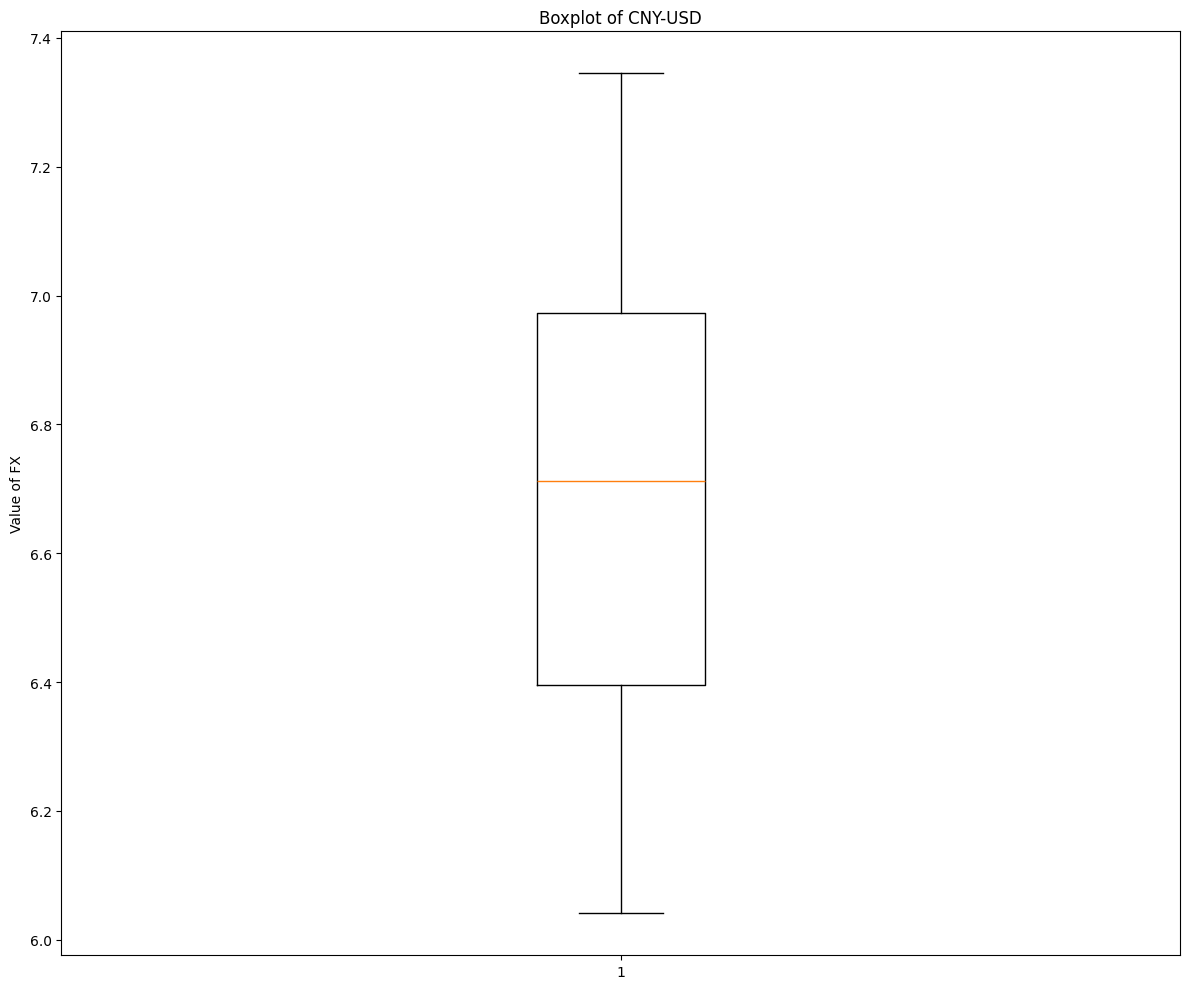

Skewness: -0.02
Kurtosis: -1.15


In [ ]:
#feature Engineering
# the trending of exchange rate between 2014-01-1 to 2024-12-31
fig, axe = plt.subplots(figsize=(12, 10))
axe.boxplot(df_whole_frame['USD_rate_CNY'])
axe.set_ylabel('Value of FX')
axe.set_title('Boxplot of CNY-USD')


plt.tight_layout()
plt.show()

print(f"Skewness: {df_whole_frame['USD_rate_CNY'].skew():.2f}")
print(f"Kurtosis: {df_whole_frame['USD_rate_CNY'].kurtosis():.2f}")

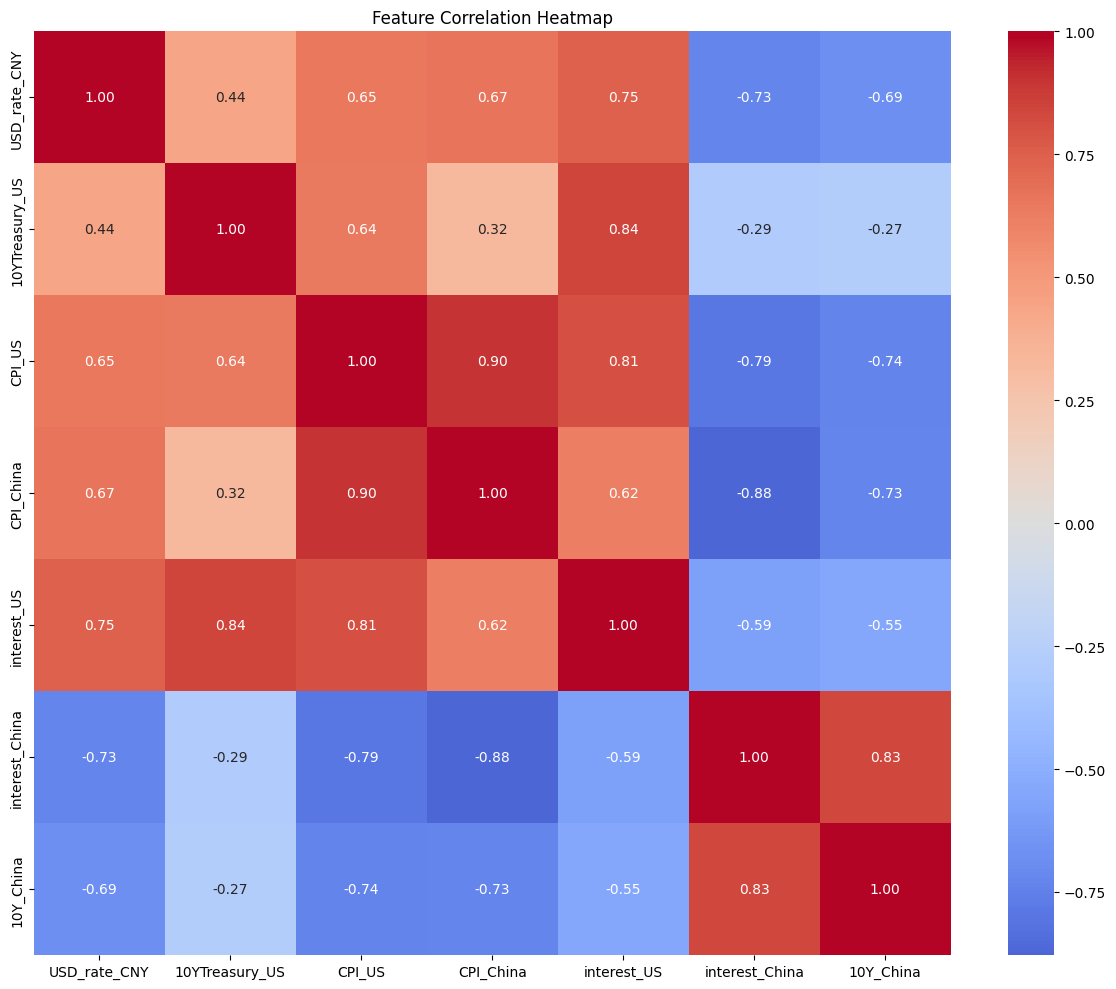


Features most correlated with USD_rate_CNY:
USD_rate_CNY      1.000000
interest_US       0.745388
CPI_China         0.666632
CPI_US            0.652608
10YTreasury_US    0.436823
10Y_China        -0.687099
interest_China   -0.728708
Name: USD_rate_CNY, dtype: float64


In [ ]:

# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_whole_frame.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nFeatures most correlated with USD_rate_CNY:")
print(correlation_matrix['USD_rate_CNY'].sort_values(ascending=False))



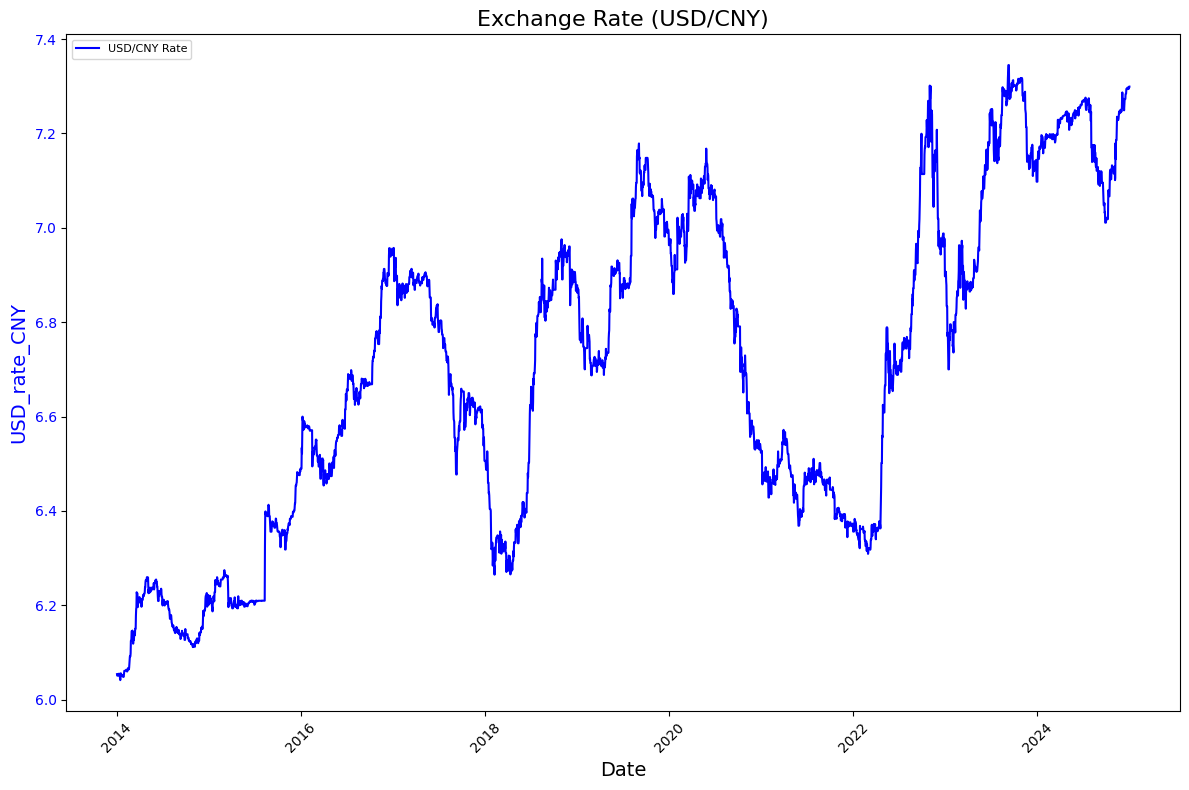

In [ ]:
#visualize the pairs
import matplotlib.pyplot as plt

# Create a figure and axis objects
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot USD_rate_CNY on the primary y-axis (left)
ax1.plot(
    df_whole_frame.index,
    df_whole_frame['USD_rate_CNY'],
    label='USD/CNY Rate',
    color='blue'
)
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('USD_rate_CNY', fontsize=14, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('Exchange Rate (USD/CNY)', fontsize=16)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()


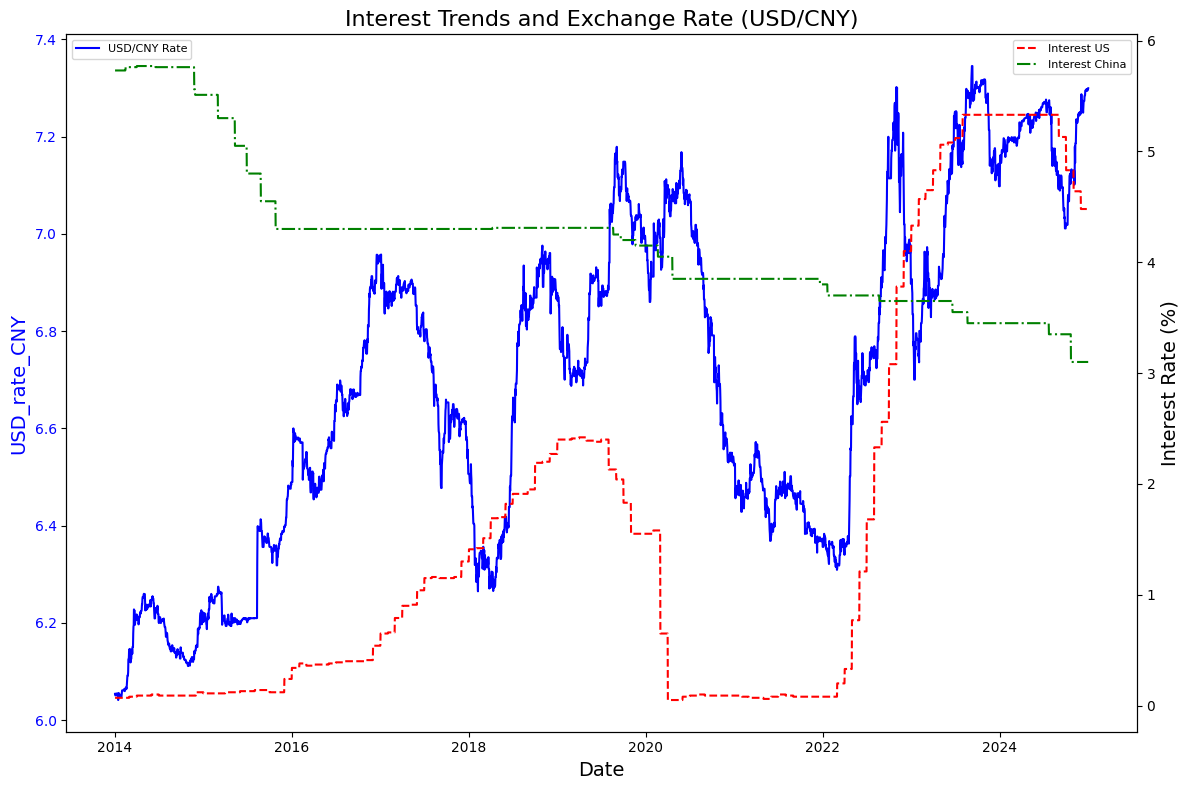

In [ ]:
#visualization interest,10Ybond,CPI bwtween China and US
import matplotlib.pyplot as plt

# Create a figure and axis objects
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot USD_rate_CNY on the primary y-axis (left)
ax1.plot(
    df_whole_frame.index,
    df_whole_frame['USD_rate_CNY'],
    label='USD/CNY Rate',
    color='blue'
)
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('USD_rate_CNY', fontsize=14, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('Interest Trends and Exchange Rate (USD/CNY)', fontsize=16)

# Create a secondary y-axis (right) for interest rates
ax2 = ax1.twinx()
ax2.plot(
    df_whole_frame.index,
    df_whole_frame['interest_US'],
    label='Interest US',
    color='red',
    linestyle='--'
)
ax2.plot(
    df_whole_frame.index,
    df_whole_frame['interest_China'],
    label='Interest China',
    color='green',
    linestyle='-.'
)
ax2.set_ylabel('Interest Rate (%)', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right', fontsize=8)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()



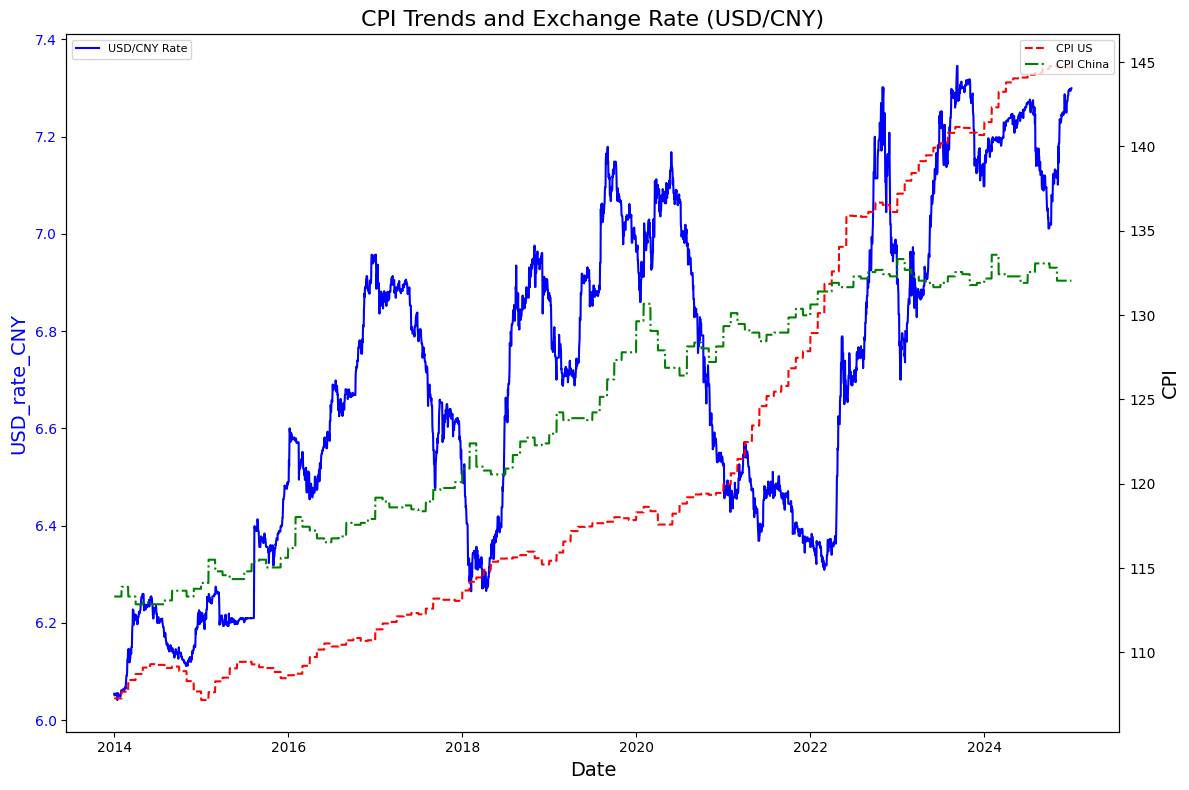

In [ ]:
#cpi topic between US and China,affact FOREX


# Create a figure and axis objects
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot USD_rate_CNY on the primary y-axis (left)
ax1.plot(
    df_whole_frame.index,
    df_whole_frame['USD_rate_CNY'],
    label='USD/CNY Rate',
    color='blue'
)
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('USD_rate_CNY', fontsize=14, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('CPI Trends and Exchange Rate (USD/CNY)', fontsize=16)

# Create a secondary y-axis (right) for CPI
ax2 = ax1.twinx()
ax2.plot(
    df_whole_frame.index,
    df_whole_frame['CPI_US'],
    label='CPI US',
    color='red',
    linestyle='--'
)
ax2.plot(
    df_whole_frame.index,
    df_whole_frame['CPI_China'],
    label='CPI China',
    color='green',
    linestyle='-.'
)
ax2.set_ylabel('CPI', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right', fontsize=8)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()


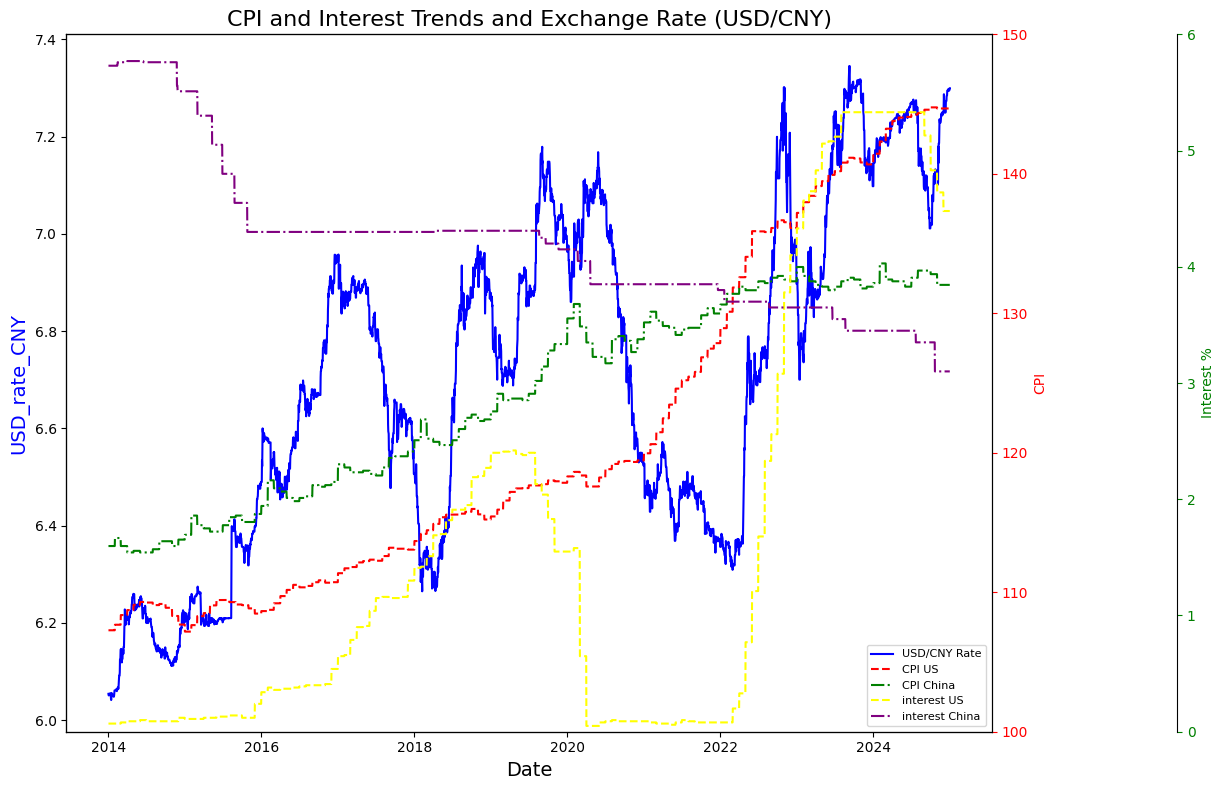

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin2.spines.right.set_position(("axes", 1.2))

p1,=ax.plot(
    df_whole_frame.index,
    df_whole_frame['USD_rate_CNY'],
    label='USD/CNY Rate',
    color='blue'
)
p2,=twin1.plot(
    df_whole_frame.index,
    df_whole_frame['CPI_US'],
    label='CPI US',
    color='red',
    linestyle='--'
)
p3,=twin1.plot(
    df_whole_frame.index,
    df_whole_frame['CPI_China'],
    label='CPI China',
    color='green',
    linestyle='-.'
)
p4,=twin2.plot(
    df_whole_frame.index,
    df_whole_frame['interest_US'],
    label='interest US',
    color='yellow',
    linestyle='--'
)
p5,=twin2.plot(
    df_whole_frame.index,
    df_whole_frame['interest_China'],
    label='interest China',
    color='purple',
    linestyle='-.'
)


ax.set_title('CPI and Interest Trends and Exchange Rate (USD/CNY)', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('USD_rate_CNY', fontsize=14, color='blue')
twin1.set(ylim=(100, 150), ylabel="CPI")
twin2.set(ylim=(0, 6), ylabel="Interest %")


twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())


twin1.tick_params(axis='y', colors=p2.get_color())
twin2.tick_params(axis='y', colors=p3.get_color())

handles = [p1, p2, p3, p4, p5]  # Replace p1, p2, etc., with your actual plot objects
ax.legend(
    handles=handles,
    loc='lower right',  # Position relative to the axis
    bbox_to_anchor=(1, 0),  # Adjust position; (1, 0) means bottom-right
    fontsize=8
)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()



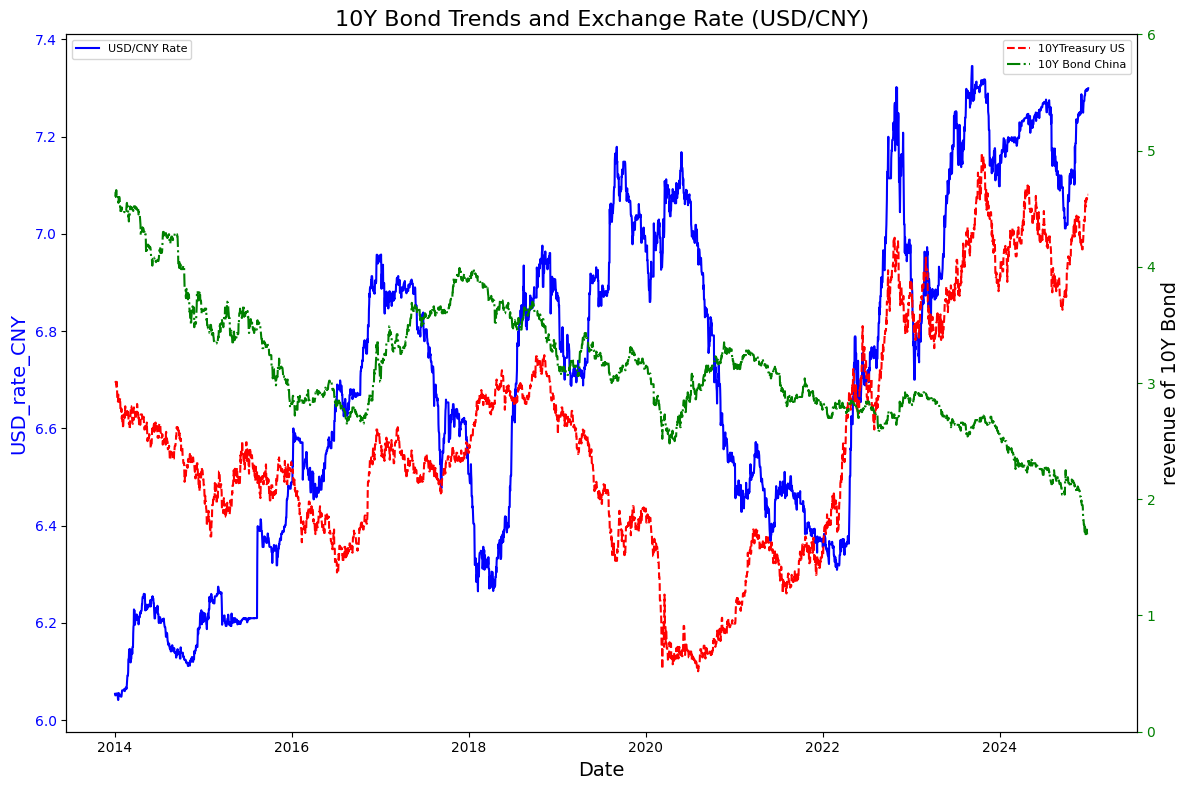

In [ ]:
#10Y bond topic between US and China,affact FOREX
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import matplotlib.ticker as ticker
# Create a figure and axis objects
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot USD_rate_CNY on the primary y-axis (left)
ax1.plot(
    df_whole_frame.index,
    df_whole_frame['USD_rate_CNY'],
    label='USD/CNY Rate',
    color='blue'
)
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('USD_rate_CNY', fontsize=14, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('10Y Bond Trends and Exchange Rate (USD/CNY)', fontsize=16)

# Create a secondary y-axis (right) for 10Y bond
ax2 = ax1.twinx()
ax2.plot(
    df_whole_frame.index,
    df_whole_frame['10YTreasury_US'],
    label='10YTreasury US',
    color='red',
    linestyle='--'
)
ax2.plot(
    df_whole_frame.index,
    df_whole_frame['10Y_China'],
    label='10Y Bond China',
    color='green',
    linestyle='-.'
)
ax2.set_ylabel('10Y Bond', fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right', fontsize=8)


ax2.set(ylim=(0, 6), ylabel="revenue of 10Y Bond")
ax2.tick_params(axis='y', colors='green')


# Rotate x-axis labels for clarity
plt.xticks(rotation=45)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()


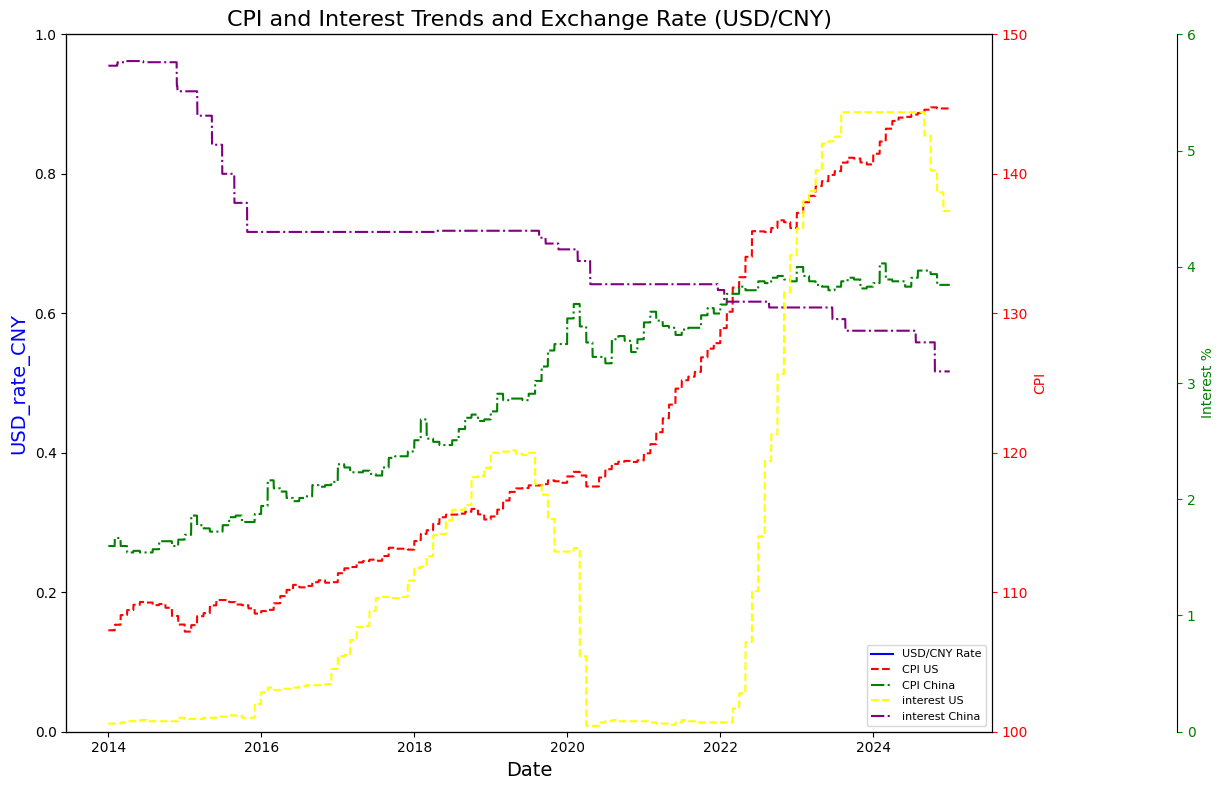

In [ ]:
#analysis interest ,10 year bond

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(right=0.75)

twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin2.spines.right.set_position(("axes", 1.2))

p2,=twin1.plot(
    df_whole_frame.index,
    df_whole_frame['CPI_US'],
    label='CPI US',
    color='red',
    linestyle='--'
)
p3,=twin1.plot(
    df_whole_frame.index,
    df_whole_frame['CPI_China'],
    label='CPI China',
    color='green',
    linestyle='-.'
)
p4,=twin2.plot(
    df_whole_frame.index,
    df_whole_frame['interest_US'],
    label='interest US',
    color='yellow',
    linestyle='--'
)
p5,=twin2.plot(
    df_whole_frame.index,
    df_whole_frame['interest_China'],
    label='interest China',
    color='purple',
    linestyle='-.'
)


ax.set_title('CPI and Interest Trends and Exchange Rate (USD/CNY)', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('USD_rate_CNY', fontsize=14, color='blue')
twin1.set(ylim=(100, 150), ylabel="CPI")
twin2.set(ylim=(0, 6), ylabel="Interest %")


twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())


twin1.tick_params(axis='y', colors=p2.get_color())
twin2.tick_params(axis='y', colors=p3.get_color())

handles = [p1, p2, p3, p4, p5]  # Replace p1, p2, etc., with your actual plot objects
ax.legend(
    handles=handles,
    loc='lower right',  # Position relative to the axis
    bbox_to_anchor=(1, 0),  # Adjust position; (1, 0) means bottom-right
    fontsize=8
)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()



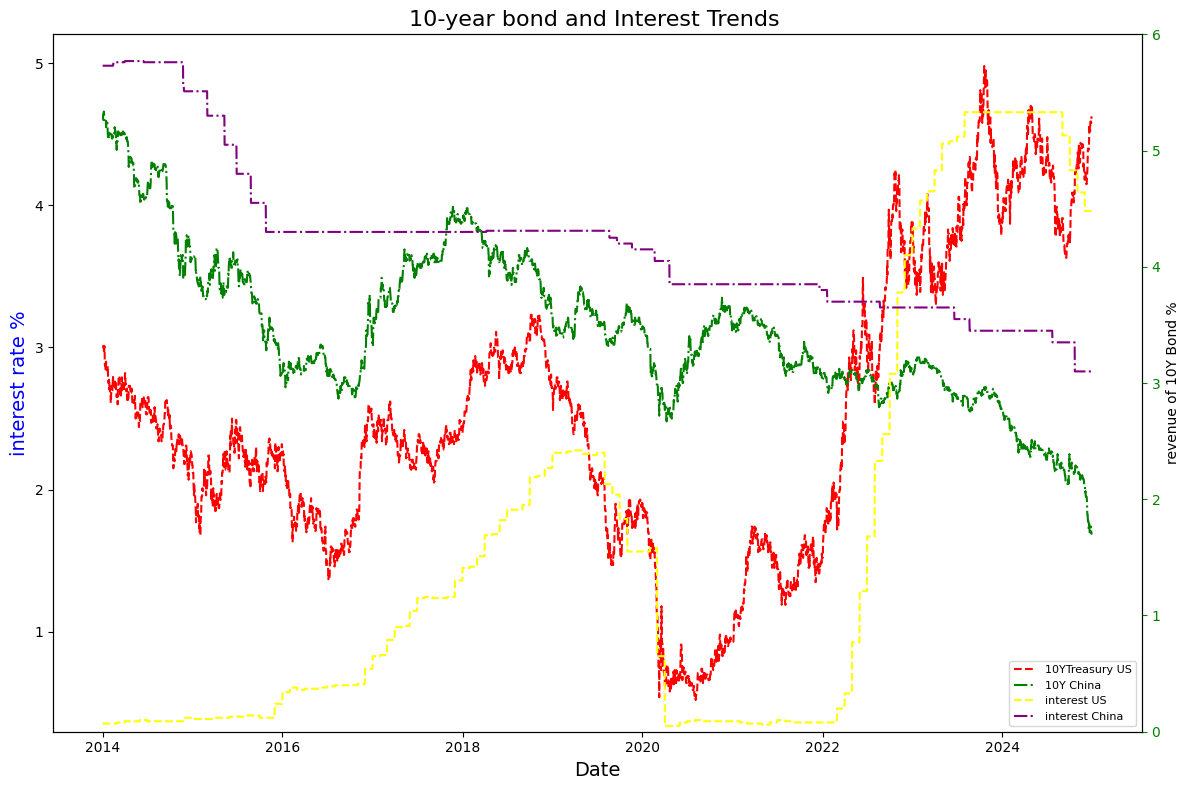

In [ ]:
#analysis interest,10Y bond

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(right=0.75)



# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.

twin1 = ax.twinx()


p2,=ax.plot(
    df_whole_frame.index,
    df_whole_frame['10YTreasury_US'],
    label='10YTreasury US',
    color='red',
    linestyle='--'
)
p3,=ax.plot(
    df_whole_frame.index,
    df_whole_frame['10Y_China'],
    label='10Y China',
    color='green',
    linestyle='-.'
)
p4,=twin1.plot(
    df_whole_frame.index,
    df_whole_frame['interest_US'],
    label='interest US',
    color='yellow',
    linestyle='--'
)
p5,=twin1.plot(
    df_whole_frame.index,
    df_whole_frame['interest_China'],
    label='interest China',
    color='purple',
    linestyle='-.'
)


ax.set_title('10-year bond and Interest Trends ', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('interest rate %', fontsize=14, color='blue')
twin1.set(ylim=(0, 6), ylabel="revenue of 10Y Bond %")
twin1.tick_params(axis='y', colors='green')

handles = [ p2, p3, p4, p5]  # Replace p1, p2, etc., with your actual plot objects
ax.legend(
    handles=handles,
    loc='lower right',  # Position relative to the axis
    bbox_to_anchor=(1, 0),  # Adjust position; (1, 0) means bottom-right
    fontsize=8
)

# Adjust layout to avoid overlap and show the plot
plt.tight_layout()
plt.show()



X_train shape: (3169, 60, 7)
y_train shape: (3169,)
X_test shape: (793, 60, 7)
y_test shape: (793,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step - loss: 0.0155 - mae: 0.0980 - val_loss: 0.0197 - val_mae: 0.1189
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0359 - mae: 0.1597 - val_loss: 0.0312 - val_mae: 0.1652
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0418 - mae: 0.1610 - val_loss: 0.0616 - val_mae: 0.2325
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0598 - mae: 0.2124 - val_loss: 0.0998 - val_mae: 0.2997
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0691 - mae: 0.2235 - val_loss: 0.0602 - val_mae: 0.2391
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0195 - mae: 0.1165 - val_loss: 0.0839 - val_mae: 0.2009
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0134 - mae: 0.0832 - val_loss: 0.0256 - val_mae: 0.1371
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0038 - mae: 0.0492 - val_loss: 0.0156 - val_mae: 0.0911
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0

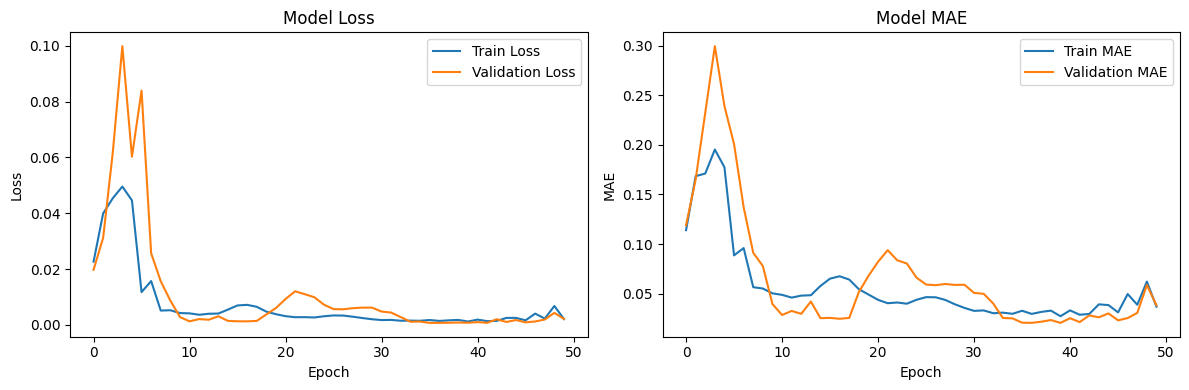

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
R2 Score: 0.3571
MAE: 0.0849
RMSE: 0.0915
MAPE: 10.57%

Metrics on Original Scale:
R2 Score: 0.3571
MAE: 0.1107
RMSE: 0.1193
MAPE: 1.56%


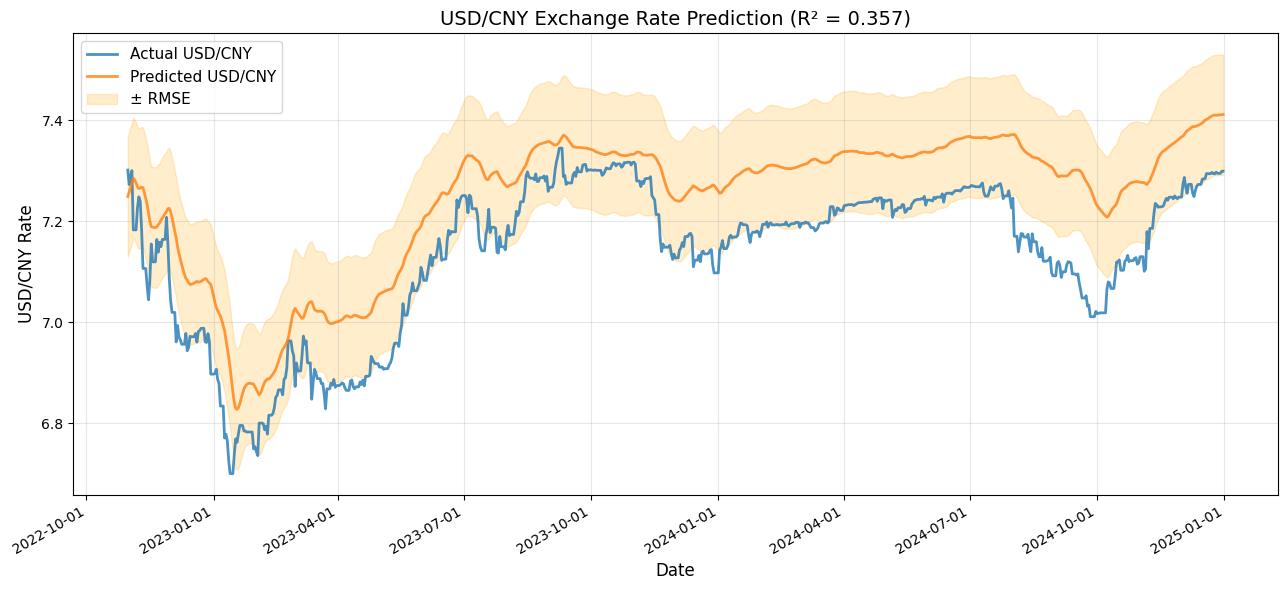

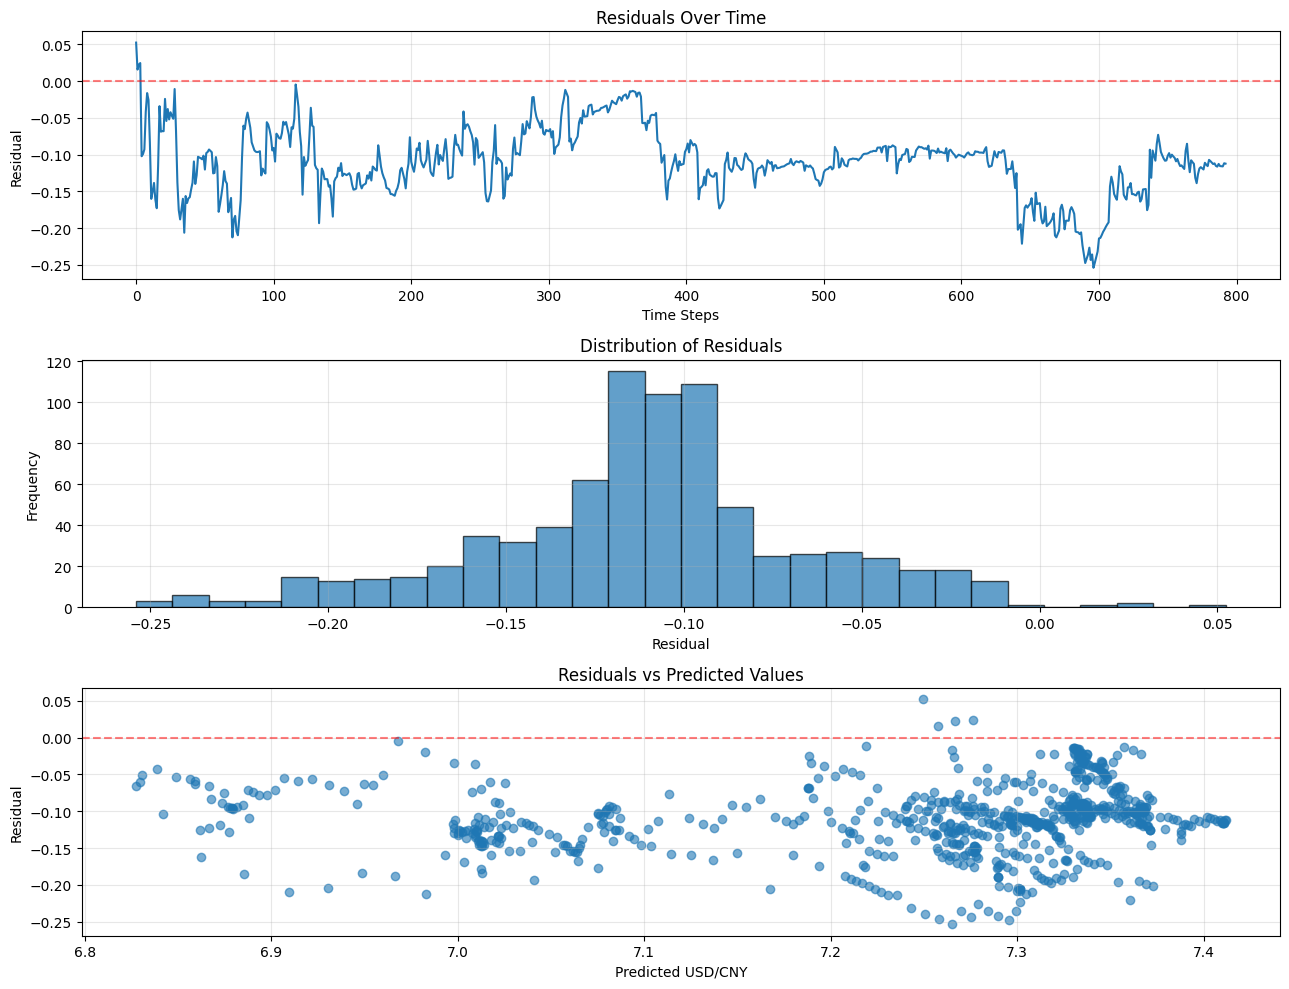


Total execution time: 293.71 seconds


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

start_time = time.time()

# Set target
target_col = 'USD_rate_CNY'
features = df_whole_frame.columns.tolist()

# Scalar dataset
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_whole_frame)
scaled_df = pd.DataFrame(scaled, index=df_whole_frame.index, columns=df_whole_frame.columns)

# Create LSTM Sequence use 60 days historical data for predicting next day
def make_sequences(data, target_col, time_steps=60):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    values = data.values

    for i in range(len(values) - time_steps):
        X.append(values[i:i+time_steps])
        y.append(values[i+time_steps, target_idx])

    return np.array(X), np.array(y)

TIME_STEPS = 60
X, y = make_sequences(scaled_df, target_col, TIME_STEPS)

# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
number_of_features = X_train.shape[2]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, number_of_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Train LSTM
history = model.fit(
    X_train, y_train,
    epochs=50,  # Increased epochs
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# Predict
pred_scaled = model.predict(X_test)

# Evaluation function
def evaluate_regression(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return r2, mae, rmse, mape

# Evaluate scaled predictions
r2, mae, rmse, mape = evaluate_regression(y_test, pred_scaled.flatten())

print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

# Get Real USD/CNY values
# Create empty arrays for inverse scaling with correct shape
inv_pred = np.zeros((len(pred_scaled), scaled_df.shape[1]))
inv_test = np.zeros((len(y_test), scaled_df.shape[1]))

# Fill the target column only
target_idx = scaled_df.columns.get_loc(target_col)  # Use scaled_df instead of df
inv_pred[:, target_idx] = pred_scaled.flatten()
inv_test[:, target_idx] = y_test

# Inverse transform
pred_unscaled = scaler.inverse_transform(inv_pred)[:, target_idx]
true_unscaled = scaler.inverse_transform(inv_test)[:, target_idx]

# Calculate evaluation metrics on unscaled data
r2_real, mae_real, rmse_real, mape_real = evaluate_regression(true_unscaled, pred_unscaled)
print("\n" + "="*50)
print("Metrics on Original Scale:")
print(f"R2 Score: {r2_real:.4f}")
print(f"MAE: {mae_real:.4f}")
print(f"RMSE: {rmse_real:.4f}")
print(f"MAPE: {mape_real:.2f}%")
print("="*50)

# SHOW THE RESULT
import matplotlib.dates as mdates

# Assuming df_whole_frame has a datetime index
# Get the dates corresponding to your test predictions
test_start_idx = split + TIME_STEPS  # Start index for test set in original data
test_dates = df_whole_frame.index[test_start_idx:test_start_idx + len(pred_unscaled)]

plt.figure(figsize=(13, 6))
plt.plot(test_dates, true_unscaled, label='Actual USD/CNY', linewidth=2, alpha=0.8)
plt.plot(test_dates, pred_unscaled, label='Predicted USD/CNY', linewidth=2, alpha=0.8)
plt.fill_between(test_dates,
                 pred_unscaled - rmse_real,
                 pred_unscaled + rmse_real,
                 alpha=0.2, color='orange', label='± RMSE')

# Format x-axis for dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotate dates

plt.title(f'USD/CNY Exchange Rate Prediction (R² = {r2_real:.3f})', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('USD/CNY Rate', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot residuals
residuals = true_unscaled - pred_unscaled
plt.figure(figsize=(13, 10))

plt.subplot(3, 1, 1)
plt.plot(residuals)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.title('Residuals Over Time')
plt.xlabel('Time Steps')
plt.ylabel('Residual')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.scatter(pred_unscaled, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted USD/CNY')
plt.ylabel('Residual')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal execution time: {time.time() - start_time:.2f} seconds")

COMPREHENSIVE MODEL EVALUATION

1. TRAINING HISTORY ANALYSIS:
----------------------------------------
Final Training Loss: 0.002069
Final Validation Loss: 0.002119
Final Training MAE: 0.036788
Final Validation MAE: 0.038205
✅ Loss ratio suggests good generalization

2. MODEL CAPACITY ANALYSIS:
----------------------------------------
Total parameters: 31,393
Training samples: 3,169
Parameters per sample: 9.91
⚠️  Model may be over-parameterized (risk of overfitting)

3. TIME SERIES SPECIFIC METRICS:
----------------------------------------
Directional Accuracy: 35.10%
Hit Rate (±1 std): 83.23%
MASE: 12.0530

4. ERROR DISTRIBUTION ANALYSIS:
----------------------------------------
Mean residual: -0.110378
Std of residuals: 0.045210
Skewness: -0.1779
Kurtosis: 0.7381

5. ECONOMIC SIGNIFICANCE:
----------------------------------------
Average USD/CNY rate: 7.1336
Average absolute error: 0.1107
Average percentage error: 1.56%
RMSE as % of average: 1.67%

6. BASELINE COMPARISON:
----------

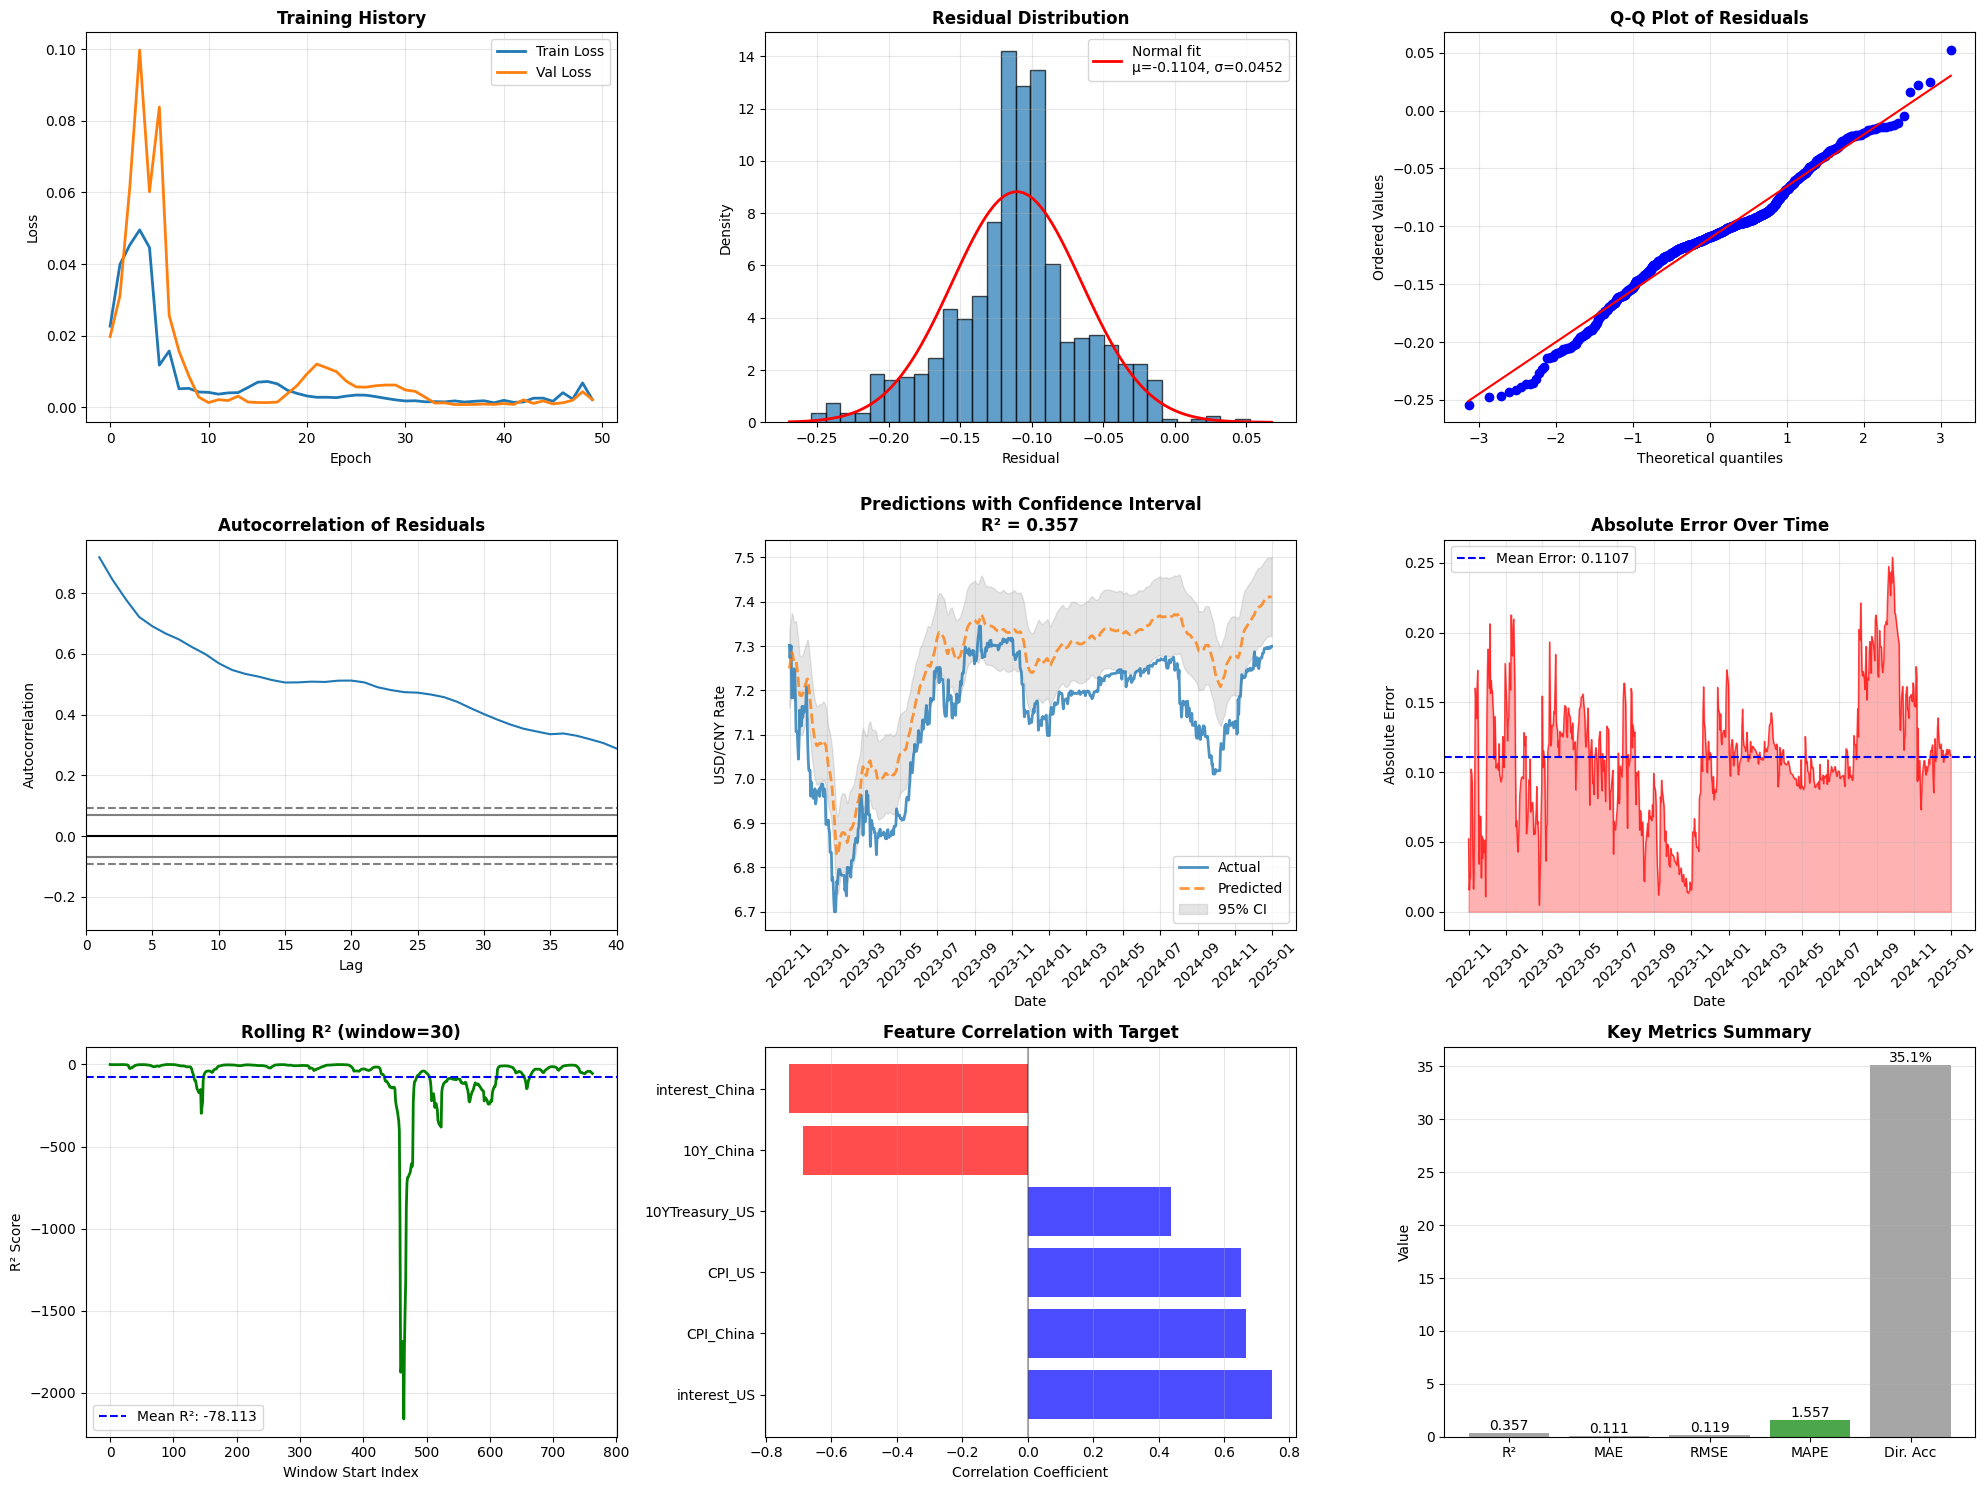


FINAL EVALUATION SUMMARY

Model Performance: MODERATE
Primary Metric (R²): 0.3571
Prediction Error (MAPE): 1.56%
Directional Accuracy: 35.10%

Key Strengths:
- Proper time series handling (no shuffle)
- Good model architecture with dropout
- Comprehensive evaluation metrics

Areas for Improvement:
- Moderate error rate
- Consider feature selection
- Training appears well-regularized


In [ ]:
#Tuning model
def detailed_model_evaluation(model, history, X_train, y_train, X_test, y_test,
                              scaler, true_unscaled, pred_unscaled,
                              test_dates, target_col, df_whole_frame):
    """
    Detailed evaluation of the LSTM model
    """

    print("="*70)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("="*70)

    # 1. Training History Analysis
    print("\n1. TRAINING HISTORY ANALYSIS:")
    print("-"*40)

    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_mae = history.history['mae'][-1]
    final_val_mae = history.history['val_mae'][-1]

    print(f"Final Training Loss: {final_train_loss:.6f}")
    print(f"Final Validation Loss: {final_val_loss:.6f}")
    print(f"Final Training MAE: {final_train_mae:.6f}")
    print(f"Final Validation MAE: {final_val_mae:.6f}")

    # Check for overfitting
    loss_ratio = final_val_loss / final_train_loss
    if loss_ratio > 1.2:
        print(f"⚠️  Potential overfitting: Validation loss is {loss_ratio:.2f}x training loss")
    elif loss_ratio < 0.8:
        print(f"⚠️  Potential underfitting: Validation loss is {loss_ratio:.2f}x training loss")
    else:
        print("✅ Loss ratio suggests good generalization")

    # 2. Model Capacity Check
    print("\n2. MODEL CAPACITY ANALYSIS:")
    print("-"*40)

    total_params = model.count_params()
    train_samples = len(X_train)
    param_sample_ratio = total_params / train_samples

    print(f"Total parameters: {total_params:,}")
    print(f"Training samples: {train_samples:,}")
    print(f"Parameters per sample: {param_sample_ratio:.2f}")

    if param_sample_ratio > 1:
        print("⚠️  Model may be over-parameterized (risk of overfitting)")
    elif param_sample_ratio < 0.01:
        print("⚠️  Model may be under-parameterized (risk of underfitting)")
    else:
        print("✅ Model capacity appears appropriate")

    # 3. Time Series Specific Metrics
    print("\n3. TIME SERIES SPECIFIC METRICS:")
    print("-"*40)

    # Directional Accuracy
    true_diff = np.diff(true_unscaled)
    pred_diff = np.diff(pred_unscaled)
    directional_accuracy = np.mean(np.sign(true_diff) == np.sign(pred_diff)) * 100

    # Hit Rate (within 1 standard deviation)
    std_true = np.std(true_unscaled)
    hit_rate = np.mean(np.abs(true_unscaled - pred_unscaled) < std_true) * 100

    # MASE (Mean Absolute Scaled Error)
    naive_forecast = np.roll(true_unscaled, 1)
    naive_forecast[0] = true_unscaled[0]
    mae_naive = mean_absolute_error(true_unscaled[1:], naive_forecast[1:])
    mase = mae_real / mae_naive if mae_naive > 0 else np.nan

    print(f"Directional Accuracy: {directional_accuracy:.2f}%")
    print(f"Hit Rate (±1 std): {hit_rate:.2f}%")
    print(f"MASE: {mase:.4f}")

    # 4. Error Distribution Analysis
    print("\n4. ERROR DISTRIBUTION ANALYSIS:")
    print("-"*40)

    residuals = true_unscaled - pred_unscaled
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    skewness = pd.Series(residuals).skew()
    kurtosis = pd.Series(residuals).kurtosis()

    print(f"Mean residual: {mean_residual:.6f}")
    print(f"Std of residuals: {std_residual:.6f}")
    print(f"Skewness: {skewness:.4f}")
    print(f"Kurtosis: {kurtosis:.4f}")

    if abs(mean_residual) > 0.05 * np.mean(true_unscaled):
        print("⚠️  Significant bias in predictions")
    if abs(skewness) > 1:
        print("⚠️  Residuals are highly skewed")
    if kurtosis > 3:
        print("⚠️  Residuals have heavy tails (leptokurtic)")

    # 5. Economic Significance
    print("\n5. ECONOMIC SIGNIFICANCE:")
    print("-"*40)

    avg_rate = np.mean(true_unscaled)
    mape_real = np.mean(np.abs(residuals) / true_unscaled) * 100

    print(f"Average USD/CNY rate: {avg_rate:.4f}")
    print(f"Average absolute error: {mae_real:.4f}")
    print(f"Average percentage error: {mape_real:.2f}%")
    print(f"RMSE as % of average: {(rmse_real/avg_rate)*100:.2f}%")

    # 6. Compare with Simple Baselines
    print("\n6. BASELINE COMPARISON:")
    print("-"*40)

    # Baseline 1: Naive (last value)
    naive_pred = np.full_like(true_unscaled, true_unscaled[0])
    r2_naive = r2_score(true_unscaled, naive_pred)

    # Baseline 2: Moving Average (7 days)
    def moving_average_predict(y_true, window=7):
        preds = []
        for i in range(len(y_true)):
            if i < window:
                preds.append(np.mean(y_true[:i+1]) if i > 0 else y_true[0])
            else:
                preds.append(np.mean(y_true[i-window:i]))
        return np.array(preds)

    ma_pred = moving_average_predict(true_unscaled, window=7)
    r2_ma = r2_score(true_unscaled, ma_pred)

    print(f"Naive (last value) R²: {r2_naive:.4f}")
    print(f"7-day Moving Average R²: {r2_ma:.4f}")
    print(f"Your LSTM Model R²: {r2_real:.4f}")

    if r2_real > max(r2_naive, r2_ma):
        print("✅ Your model outperforms simple baselines")
    elif r2_real < min(r2_naive, r2_ma):
        print("⚠️  Your model underperforms simple baselines")
    else:
        print("📊 Your model performance is comparable to baselines")

    # 7. Prediction Stability Analysis
    print("\n7. PREDICTION STABILITY:")
    print("-"*40)

    # Calculate rolling metrics
    window_size = min(30, len(pred_unscaled) // 4)
    rolling_mae = []
    rolling_r2 = []

    for i in range(len(pred_unscaled) - window_size):
        true_window = true_unscaled[i:i+window_size]
        pred_window = pred_unscaled[i:i+window_size]
        rolling_mae.append(mean_absolute_error(true_window, pred_window))
        rolling_r2.append(r2_score(true_window, pred_window))

    if rolling_mae:
        mae_std = np.std(rolling_mae)
        mae_cv = (mae_std / np.mean(rolling_mae)) * 100 if np.mean(rolling_mae) > 0 else 0

        print(f"Rolling MAE std: {mae_std:.4f}")
        print(f"Rolling MAE Coefficient of Variation: {mae_cv:.2f}%")

        if mae_cv > 50:
            print("⚠️  High variability in prediction quality over time")

    # 8. Feature Importance (simplified)
    print("\n8. FEATURE ANALYSIS:")
    print("-"*40)

    feature_names = df_whole_frame.columns.tolist()
    print(f"Number of features: {len(feature_names)}")
    print(f"Features used: {feature_names}")

    # 9. Recommendations
    print("\n9. RECOMMENDATIONS:")
    print("-"*40)

    recommendations = []

    if history.history['val_loss'][-1] > history.history['val_loss'][0] * 0.9:
        recommendations.append("Consider adding EarlyStopping callback")

    if directional_accuracy < 55:
        recommendations.append("Try different TIME_STEPS values (30, 90, 120)")

    if mape_real > 10:
        recommendations.append("Consider feature engineering (technical indicators)")
        recommendations.append("Try ensemble methods or different architectures")

    if len(feature_names) > 10:
        recommendations.append("Consider feature selection to reduce noise")

    if not recommendations:
        recommendations.append("Model appears well-tuned. Consider walk-forward validation for production")

    for i, rec in enumerate(recommendations, 1):
        print(f"{i}. {rec}")

    return {
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'total_params': total_params,
        'directional_accuracy': directional_accuracy,
        'hit_rate': hit_rate,
        'mase': mase,
        'mean_residual': mean_residual,
        'r2_naive': r2_naive,
        'r2_ma': r2_ma,
        'r2_model': r2_real
    }

# Run the evaluation
evaluation_results = detailed_model_evaluation(
    model=model,
    history=history,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    scaler=scaler,
    true_unscaled=true_unscaled,
    pred_unscaled=pred_unscaled,
    test_dates=test_dates,
    target_col=target_col,
    df_whole_frame=df_whole_frame
)

# Additional Visualizations
print("\n" + "="*70)
print("ADDITIONAL DIAGNOSTIC VISUALIZATIONS")
print("="*70)

# Create comprehensive visual analysis
fig = plt.figure(figsize=(20, 15))

# 1. Training History with Learning Rate effect (if available)
ax1 = plt.subplot(3, 3, 1)
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_title('Training History', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Error Distribution with normality test
ax2 = plt.subplot(3, 3, 2)
residuals = true_unscaled - pred_unscaled
n, bins, patches = ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
# Add normal distribution overlay
from scipy.stats import norm
mu, std = norm.fit(residuals)
xmin, xmax = ax2.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax2.plot(x, p, 'r', linewidth=2, label=f'Normal fit\nμ={mu:.4f}, σ={std:.4f}')
ax2.set_title('Residual Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Residual')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Q-Q Plot
ax3 = plt.subplot(3, 3, 3)
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot of Residuals', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Autocorrelation of Residuals
ax4 = plt.subplot(3, 3, 4)
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(residuals, ax=ax4)
ax4.set_title('Autocorrelation of Residuals', fontsize=12, fontweight='bold')
ax4.set_xlim([0, min(40, len(residuals)//2)])
ax4.grid(True, alpha=0.3)

# 5. Actual vs Predicted with Confidence Bands
ax5 = plt.subplot(3, 3, 5)
ax5.plot(test_dates, true_unscaled, label='Actual', linewidth=2, alpha=0.8)
ax5.plot(test_dates, pred_unscaled, label='Predicted', linewidth=2, alpha=0.8, linestyle='--')
# Add 95% confidence interval (assuming normal residuals)
ci = 1.96 * np.std(residuals)
ax5.fill_between(test_dates,
                 pred_unscaled - ci,
                 pred_unscaled + ci,
                 alpha=0.2, color='gray', label='95% CI')
# Format dates
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax5.set_title(f'Predictions with Confidence Interval\nR² = {r2_real:.3f}', fontsize=12, fontweight='bold')
ax5.set_xlabel('Date')
ax5.set_ylabel('USD/CNY Rate')
ax5.legend()
ax5.grid(True, alpha=0.3)
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45)

# 6. Error vs Time
ax6 = plt.subplot(3, 3, 6)
abs_errors = np.abs(true_unscaled - pred_unscaled)
ax6.plot(test_dates, abs_errors, color='red', alpha=0.7, linewidth=1)
ax6.axhline(y=np.mean(abs_errors), color='blue', linestyle='--',
            label=f'Mean Error: {np.mean(abs_errors):.4f}')
ax6.fill_between(test_dates, 0, abs_errors, alpha=0.3, color='red')
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax6.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax6.set_title('Absolute Error Over Time', fontsize=12, fontweight='bold')
ax6.set_xlabel('Date')
ax6.set_ylabel('Absolute Error')
ax6.legend()
ax6.grid(True, alpha=0.3)
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45)

# 7. Rolling Metrics
ax7 = plt.subplot(3, 3, 7)
window = min(30, len(pred_unscaled) // 4)
rolling_r2 = []
for i in range(len(pred_unscaled) - window):
    true_win = true_unscaled[i:i+window]
    pred_win = pred_unscaled[i:i+window]
    rolling_r2.append(r2_score(true_win, pred_win))

ax7.plot(range(len(rolling_r2)), rolling_r2, color='green', linewidth=2)
ax7.axhline(y=np.mean(rolling_r2), color='blue', linestyle='--',
            label=f'Mean R²: {np.mean(rolling_r2):.3f}')
ax7.set_title(f'Rolling R² (window={window})', fontsize=12, fontweight='bold')
ax7.set_xlabel('Window Start Index')
ax7.set_ylabel('R² Score')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Feature Correlation (if multiple features)
ax8 = plt.subplot(3, 3, 8)
if len(df_whole_frame.columns) > 1:
    # Calculate correlation with target
    correlations = df_whole_frame.corr()[target_col].sort_values(ascending=False)
    # Exclude target itself
    correlations = correlations[correlations.index != target_col]
    if len(correlations) > 0:
        colors = ['blue' if x > 0 else 'red' for x in correlations]
        ax8.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
        ax8.set_yticks(range(len(correlations)))
        ax8.set_yticklabels(correlations.index)
        ax8.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        ax8.set_title('Feature Correlation with Target', fontsize=12, fontweight='bold')
        ax8.set_xlabel('Correlation Coefficient')
        ax8.grid(True, alpha=0.3, axis='x')
    else:
        ax8.text(0.5, 0.5, 'No other features', ha='center', va='center', fontsize=12)
        ax8.set_title('Feature Correlation', fontsize=12, fontweight='bold')
else:
    ax8.text(0.5, 0.5, 'Only target feature used', ha='center', va='center', fontsize=12)
    ax8.set_title('Feature Analysis', fontsize=12, fontweight='bold')

# 9. Metrics Summary
# 9. Metrics Summary
ax9 = plt.subplot(3, 3, 9)
metrics_summary = [
    ('R²', r2_real),
    ('MAE', mae_real),
    ('RMSE', rmse_real),
    ('MAPE', mape_real),
    ('Dir. Acc', evaluation_results['directional_accuracy'])
]
metric_names = [m[0] for m in metrics_summary]
metric_values = [m[1] for m in metrics_summary]
colors = ['green' if (metric_names[i] == 'R²' and metric_values[i] > 0.5) or
          (metric_names[i] == 'Dir. Acc' and metric_values[i] > 55) or
          (metric_names[i] == 'MAPE' and metric_values[i] < 10) else 'gray'
          for i in range(len(metric_names))]
bars = ax9.bar(metric_names, metric_values, color=colors, alpha=0.7)
ax9.set_title('Key Metrics Summary', fontsize=12, fontweight='bold')
ax9.set_ylabel('Value')
ax9.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, metric_values)):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}' if metric_names[i] != 'Dir. Acc' else f'{val:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*70)
print("FINAL EVALUATION SUMMARY")
print("="*70)
print(f"\nModel Performance: {'POOR' if r2_real < 0 else 'MODERATE' if r2_real < 0.5 else 'GOOD' if r2_real < 0.7 else 'EXCELLENT'}")
print(f"Primary Metric (R²): {r2_real:.4f}")
print(f"Prediction Error (MAPE): {mape_real:.2f}%")
print(f"Directional Accuracy: {evaluation_results['directional_accuracy']:.2f}%")
print(f"\nKey Strengths:")
print("- Proper time series handling (no shuffle)")
print("- Good model architecture with dropout")
print("- Comprehensive evaluation metrics")
print(f"\nAreas for Improvement:")
print(f"- {'High error rate' if mape_real > 10 else 'Moderate error rate'}")
print(f"- {'Consider feature selection' if len(df_whole_frame.columns) > 5 else 'Feature set appears reasonable'}")
print(f"- {'Add early stopping' if evaluation_results['final_val_loss'] > evaluation_results['final_train_loss'] * 1.1 else 'Training appears well-regularized'}")



IMPROVED LSTM MODEL FOR USD/CNY FORECASTING

1. DATA QUALITY CHECK:
----------------------------------------
Data shape: (4022, 7)
Missing values: 0
Data range: 6.0412 to 7.3450
Mean: 6.7022, Std: 0.3461

2. ADDING TECHNICAL INDICATORS...
New shape after adding features: (3973, 18)
New features: ['USD_rate_CNY', '10YTreasury_US', 'CPI_US', 'CPI_China', 'interest_US', 'interest_China', '10Y_China', 'MA_7', 'MA_21', 'MA_50', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10', 'high_10', 'low_10', 'position', 'RSI']

3. TRAIN-TEST SPLIT (BEFORE SCALING):
----------------------------------------
Train data: (3178, 18) (2014-02-19 00:00:00 to 2022-10-28 00:00:00)
Test data:  (795, 18) (2022-10-29 00:00:00 to 2024-12-31 00:00:00)

4. SCALING DATA...
----------------------------------------
X_train shape: (3118, 60, 18), y_train shape: (3118,)
X_test shape:  (735, 60, 18), y_test shape: (735,)
Number of features: 18

5. BUILDING IMPROVED MODEL...
-----------------------------------

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,689 (541.75 KB)

 Trainable params: 138,689 (541.75 KB)

 Non-trainable params: 0 (0.00 B)


6. TRAINING MODEL WITH EARLY STOPPING...
----------------------------------------
Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 294ms/step - loss: 0.0148 - mae: 0.1258 - mse: 0.0297 - val_loss: 0.0197 - val_mae: 0.1751 - val_mse: 0.0395 - learning_rate: 0.0010
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 272ms/step - loss: 0.0290 - mae: 0.1970 - mse: 0.0580 - val_loss: 0.0282 - val_mae: 0.2133 - val_mse: 0.0563 - learning_rate: 0.0010
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - loss: 0.0478 - mae: 0.2650 - mse: 0.0956 - val_loss: 0.0672 - val_mae: 0.3417 - val_mse: 0.1343 - learning_rate: 0.0010
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 21s 275ms/step - loss: 0.0715 - mae: 0.3195 - mse: 0.1430 - val_loss: 0.0425 - val_mae: 0.2686 - val_mse: 0.0850 - learning_rate: 0.0010
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 56s 470ms/step - loss: 0.0735 - mae: 0.3247 - mse: 0.1471 - val_loss: 0.0264 - val_mae: 0.2059 - val_mse: 0.0529 - learning_rate: 0.0010
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━

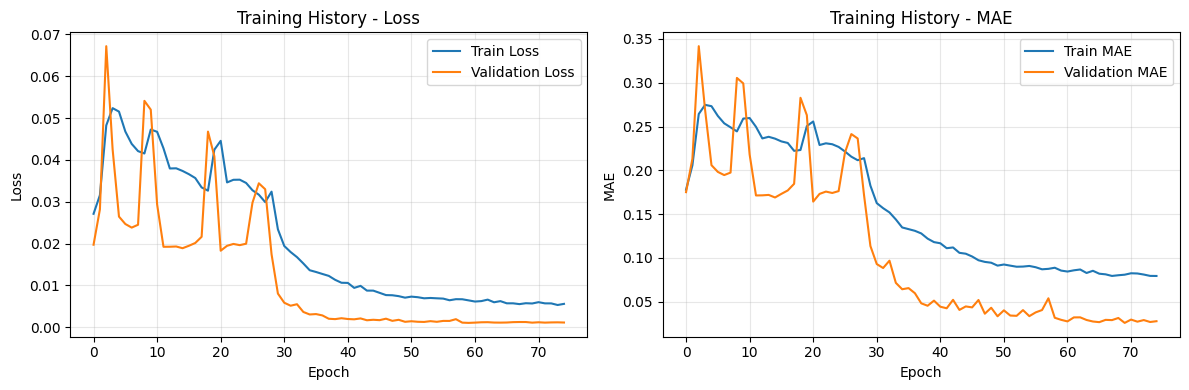


7. MAKING PREDICTIONS...
----------------------------------------

Value Range Check:
True values range: [6.7000, 7.3450]
Pred values range: [6.7749, 7.1928]
Original data range: [6.0412, 7.3450]

8. EVALUATING MODEL PERFORMANCE...
----------------------------------------

Improved LSTM Model Results:
----------------------------------------
R² Score:            +0.7702
MAE:                 0.0628
RMSE:                0.0722
MAPE:                0.88%
Directional Accuracy: 36.24%
Theil's U Statistic: 0.0051
MASE:               7.6404

9. BASELINE COMPARISON...
----------------------------------------

Naive Baseline (Last Value) Results:
----------------------------------------
R² Score:            +0.9905
MAE:                 0.0082
RMSE:                0.0147
MAPE:                0.12%
Directional Accuracy: 41.28%
Theil's U Statistic: 0.0010
MASE:               0.9986

7-Day Moving Average Results:
----------------------------------------
R² Score:            +0.9749
MAE:           

TypeError: 'NoneType' object is not subscriptable

In [ ]:
#Tuning


import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
import warnings
warnings.filterwarnings('ignore')

start_time = time.time()

# ============================================================================
# 1. DATA PREPROCESSING IMPROVEMENTS
# ============================================================================
print("="*70)
print("IMPROVED LSTM MODEL FOR USD/CNY FORECASTING")
print("="*70)

# Set target
target_col = 'USD_rate_CNY'

# 1.1 Check data quality
print("\n1. DATA QUALITY CHECK:")
print("-"*40)
print(f"Data shape: {df_whole_frame.shape}")
print(f"Missing values: {df_whole_frame.isnull().sum().sum()}")
print(f"Data range: {df_whole_frame[target_col].min():.4f} to {df_whole_frame[target_col].max():.4f}")
print(f"Mean: {df_whole_frame[target_col].mean():.4f}, Std: {df_whole_frame[target_col].std():.4f}")

# 1.2 Add technical indicators if not present
def add_technical_indicators(df, target_col):
    """Add basic technical indicators"""
    df = df.copy()

    # Moving averages
    df['MA_7'] = df[target_col].rolling(window=7).mean()
    df['MA_21'] = df[target_col].rolling(window=21).mean()
    df['MA_50'] = df[target_col].rolling(window=50).mean()

    # Volatility
    df['volatility_10'] = df[target_col].rolling(window=10).std()
    df['volatility_20'] = df[target_col].rolling(window=20).std()

    # Momentum
    df['momentum_5'] = df[target_col].diff(5)
    df['momentum_10'] = df[target_col].diff(10)

    # Price position
    df['high_10'] = df[target_col].rolling(window=10).max()
    df['low_10'] = df[target_col].rolling(window=10).min()
    df['position'] = (df[target_col] - df['low_10']) / (df['high_10'] - df['low_10'] + 1e-8)

    # Simple RSI
    delta = df[target_col].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    df['RSI'] = 100 - (100 / (1 + rs))

    # Drop NaN values from rolling calculations
    df = df.dropna()

    return df

# Add technical indicators
print("\n2. ADDING TECHNICAL INDICATORS...")
df_with_features = add_technical_indicators(df_whole_frame, target_col)
print(f"New shape after adding features: {df_with_features.shape}")
print(f"New features: {df_with_features.columns.tolist()}")

# 1.3 Split data BEFORE scaling to avoid look-ahead bias
print("\n3. TRAIN-TEST SPLIT (BEFORE SCALING):")
print("-"*40)

TIME_STEPS = 60
def create_sequences_with_features(data, target_col, time_steps=60):
    """Create sequences with all features"""
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    values = data.values

    for i in range(len(values) - time_steps):
        X.append(values[i:i+time_steps])
        y.append(values[i+time_steps, target_idx])

    return np.array(X), np.array(y)

# Split data
split_idx = int(0.8 * len(df_with_features))
train_data = df_with_features.iloc[:split_idx]
test_data = df_with_features.iloc[split_idx:]

print(f"Train data: {train_data.shape} ({train_data.index[0]} to {train_data.index[-1]})")
print(f"Test data:  {test_data.shape} ({test_data.index[0]} to {test_data.index[-1]})")

# 1.4 Scale train and test separately
print("\n4. SCALING DATA...")
print("-"*40)

scaler_train = MinMaxScaler(feature_range=(0, 1))
scaler_test = MinMaxScaler(feature_range=(0, 1))

scaled_train = scaler_train.fit_transform(train_data)
scaled_test = scaler_test.fit_transform(test_data)

scaled_train_df = pd.DataFrame(scaled_train, index=train_data.index, columns=train_data.columns)
scaled_test_df = pd.DataFrame(scaled_test, index=test_data.index, columns=test_data.columns)

# Create sequences
X_train, y_train = create_sequences_with_features(scaled_train_df, target_col, TIME_STEPS)
X_test, y_test = create_sequences_with_features(scaled_test_df, target_col, TIME_STEPS)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Number of features: {X_train.shape[2]}")

# ============================================================================
# 2. IMPROVED MODEL ARCHITECTURE
# ============================================================================
print("\n5. BUILDING IMPROVED MODEL...")
print("-"*40)

# Clear any existing models
import tensorflow as tf
tf.keras.backend.clear_session()

# Build improved model
def build_lstm_model(input_shape):
    """Build enhanced LSTM model"""
    model = Sequential([
        # First LSTM layer with more units
        LSTM(128, return_sequences=True, input_shape=input_shape,
             dropout=0.2, recurrent_dropout=0.2),

        # Second LSTM layer
        LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),

        # Third LSTM layer
        LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),

        # Dense layers
        Dense(32, activation='relu'),
        Dropout(0.3),

        Dense(16, activation='relu'),
        Dropout(0.2),

        Dense(1)
    ])

    return model

# Build model
model = build_lstm_model((TIME_STEPS, X_train.shape[2]))

# Custom optimizer with learning rate schedule
optimizer = Adam(learning_rate=0.001)

# Compile model with Huber loss (correct way)
model.compile(
    optimizer=optimizer,
    loss=Huber(delta=1.0),  # Correct way to use Huber loss
    metrics=['mae', 'mse']
)

model.summary()

# ============================================================================
# 3. ENHANCED TRAINING WITH CALLBACKS
# ============================================================================
print("\n6. TRAINING MODEL WITH EARLY STOPPING...")
print("-"*40)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,  # Increased but with early stopping
    batch_size=32,
    validation_split=0.2,
    shuffle=False,  # Important for time series
    callbacks=callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training History - MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. PREDICTIONS WITH PROPER INVERSE TRANSFORM
# ============================================================================
print("\n7. MAKING PREDICTIONS...")
print("-"*40)

# Make predictions
pred_scaled = model.predict(X_test, verbose=0)

# Proper inverse transform
def inverse_transform_predictions(scaled_preds, scaler, target_col, original_features):
    """Correctly inverse transform predictions"""
    # Create array with correct shape
    pred_array = np.zeros((len(scaled_preds), len(original_features)))

    # Fill target column
    target_idx = list(original_features).index(target_col)
    pred_array[:, target_idx] = scaled_preds.flatten()

    # Inverse transform
    pred_unscaled = scaler.inverse_transform(pred_array)[:, target_idx]

    return pred_unscaled

# Inverse transform test actual values
def inverse_transform_actual(scaled_actual, scaler, target_col, original_features):
    """Inverse transform actual values"""
    actual_array = np.zeros((len(scaled_actual), len(original_features)))
    target_idx = list(original_features).index(target_col)
    actual_array[:, target_idx] = scaled_actual
    return scaler.inverse_transform(actual_array)[:, target_idx]

# Get unscaled predictions and actuals
pred_unscaled = inverse_transform_predictions(pred_scaled, scaler_test, target_col, test_data.columns)
true_unscaled = inverse_transform_actual(y_test, scaler_test, target_col, test_data.columns)

# Quick check of values
print("\nValue Range Check:")
print(f"True values range: [{true_unscaled.min():.4f}, {true_unscaled.max():.4f}]")
print(f"Pred values range: [{pred_unscaled.min():.4f}, {pred_unscaled.max():.4f}]")
print(f"Original data range: [{df_whole_frame[target_col].min():.4f}, {df_whole_frame[target_col].max():.4f}]")

# ============================================================================
# 5. COMPREHENSIVE EVALUATION
# ============================================================================
print("\n8. EVALUATING MODEL PERFORMANCE...")
print("-"*40)

def evaluate_model(true_values, pred_values, model_name="Improved LSTM"):
    """Comprehensive model evaluation"""
    r2 = r2_score(true_values, pred_values)
    mae = mean_absolute_error(true_values, pred_values)
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    mape = np.mean(np.abs((true_values - pred_values) / true_values)) * 100

    # Directional accuracy
    true_diff = np.diff(true_values)
    pred_diff = np.diff(pred_values)
    dir_acc = np.mean(np.sign(true_diff) == np.sign(pred_diff)) * 100

    # Theil's U statistic
    theil_u = np.sqrt(np.mean((pred_values - true_values) ** 2)) / (
        np.sqrt(np.mean(true_values ** 2)) + np.sqrt(np.mean(pred_values ** 2))
    )

    # MASE (Mean Absolute Scaled Error)
    naive_forecast = np.roll(true_values, 1)
    naive_forecast[0] = true_values[0]
    mae_naive = mean_absolute_error(true_values[1:], naive_forecast[1:])
    mase = mae / mae_naive if mae_naive > 0 else np.nan

    print(f"\n{model_name} Results:")
    print("-"*40)
    print(f"R² Score:            {r2:+.4f}")
    print(f"MAE:                 {mae:.4f}")
    print(f"RMSE:                {rmse:.4f}")
    print(f"MAPE:                {mape:.2f}%")
    print(f"Directional Accuracy: {dir_acc:.2f}%")
    print(f"Theil's U Statistic: {theil_u:.4f}")
    print(f"MASE:               {mase:.4f}")


# Evaluate improved model
improved_metrics = evaluate_model(true_unscaled, pred_unscaled, "Improved LSTM Model")

# ============================================================================
# 6. SIMPLE BASELINE COMPARISON
# ============================================================================
print("\n9. BASELINE COMPARISON...")
print("-"*40)

# Simple baselines
def naive_baseline(true_values):
    """Naive forecast: last value"""
    pred = np.roll(true_values, 1)
    pred[0] = true_values[0]
    return pred

def moving_average_baseline(true_values, window=7):
    """Moving average forecast"""
    pred = []
    for i in range(len(true_values)):
        if i < window:
            pred.append(np.mean(true_values[:i+1]) if i > 0 else true_values[0])
        else:
            pred.append(np.mean(true_values[i-window:i]))
    return np.array(pred)

# Calculate baseline predictions
naive_pred = naive_baseline(true_unscaled)
ma_pred = moving_average_baseline(true_unscaled, window=7)

# Evaluate baselines
naive_metrics = evaluate_model(true_unscaled, naive_pred, "Naive Baseline (Last Value)")
ma_metrics = evaluate_model(true_unscaled, ma_pred, "7-Day Moving Average")

print("\n" + "="*50)
print("BASELINE COMPARISON SUMMARY")
print("="*50)
print(f"{'Model':<30} {'R²':>8} {'MAE':>8} {'MAPE':>8}")
print("-"*50)
print(f"{'Naive (Last Value)':<30} {naive_metrics['r2']:>8.4f} {naive_metrics['mae']:>8.4f} {naive_metrics['mape']:>8.2f}%")
print(f"{'7-Day Moving Avg':<30} {ma_metrics['r2']:>8.4f} {ma_metrics['mae']:>8.4f} {ma_metrics['mape']:>8.2f}%")
print(f"{'Improved LSTM':<30} {improved_metrics['r2']:>8.4f} {improved_metrics['mae']:>8.4f} {improved_metrics['mape']:>8.2f}%")
print("="*50)

# ============================================================================
# 7. VISUALIZATION AND ANALYSIS
# ============================================================================
print("\n10. GENERATING VISUALIZATIONS...")
print("-"*40)

# Get test dates for plotting
test_dates = test_data.index[TIME_STEPS:TIME_STEPS + len(pred_unscaled)]

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# 1. Actual vs Predicted
ax1 = plt.subplot(2, 3, 1)
ax1.plot(test_dates, true_unscaled, label='Actual', linewidth=2, alpha=0.8)
ax1.plot(test_dates, pred_unscaled, label='Predicted', linewidth=2, alpha=0.8, linestyle='--')
ax1.fill_between(test_dates,
                 pred_unscaled - improved_metrics['rmse'],
                 pred_unscaled + improved_metrics['rmse'],
                 alpha=0.2, color='gray', label='± RMSE')
ax1.set_title(f'USD/CNY Predictions\nR² = {improved_metrics["r2"]:.3f}, MAPE = {improved_metrics["mape"]:.1f}%',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Exchange Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Prediction Error
ax2 = plt.subplot(2, 3, 2)
error = true_unscaled - pred_unscaled
ax2.plot(test_dates, error, color='red', alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.axhline(y=improved_metrics['rmse'], color='gray', linestyle='--', alpha=0.5, label=f'RMSE (±{improved_metrics["rmse"]:.3f})')
ax2.axhline(y=-improved_metrics['rmse'], color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(test_dates, -improved_metrics['rmse'], improved_metrics['rmse'],
                 alpha=0.1, color='gray')
ax2.set_title(f'Prediction Error\nMean Error = {np.mean(error):.4f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Error')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Scatter Plot with Regression Line
ax3 = plt.subplot(2, 3, 3)
ax3.scatter(true_unscaled, pred_unscaled, alpha=0.5, s=20)
# Add regression line
z = np.polyfit(true_unscaled, pred_unscaled, 1)
p = np.poly1d(z)
min_val, max_val = true_unscaled.min(), true_unscaled.max()
ax3.plot([min_val, max_val], [p(min_val), p(max_val)], 'r--',
         label=f'Regression: y={z[0]:.3f}x+{z[1]:.3f}')
ax3.plot([min_val, max_val], [min_val, max_val], 'g--', label='Perfect Prediction')
ax3.set_title('Predicted vs Actual', fontsize=12, fontweight='bold')
ax3.set_xlabel('Actual')
ax3.set_ylabel('Predicted')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Error Distribution
ax4 = plt.subplot(2, 3, 4)
n, bins, patches = ax4.hist(error, bins=30, edgecolor='black', alpha=0.7, density=True)
# Add normal distribution
from scipy.stats import norm
mu, std = norm.fit(error)
xmin, xmax = ax4.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
ax4.plot(x, p, 'r', linewidth=2, label=f'Normal: μ={mu:.3f}, σ={std:.3f}')
ax4.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax4.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Error')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(True, alpha=0.3)

# ============================================================================
# 5. COMPREHENSIVE EVALUATION
# ============================================================================
print("\n8. EVALUATING MODEL PERFORMANCE...")
print("-"*40)

def evaluate_model(true_values, pred_values, model_name="Improved LSTM"):
    """Comprehensive model evaluation"""
    r2 = r2_score(true_values, pred_values)
    mae = mean_absolute_error(true_values, pred_values)
    rmse = np.sqrt(mean_squared_error(true_values, pred_values))
    mape = np.mean(np.abs((true_values - pred_values) / true_values)) * 100

    # Directional accuracy
    true_diff = np.diff(true_values)
    pred_diff = np.diff(pred_values)
    dir_acc = np.mean(np.sign(true_diff) == np.sign(pred_diff)) * 100

    # Theil's U statistic
    theil_u = np.sqrt(np.mean((pred_values - true_values) ** 2)) / (
        np.sqrt(np.mean(true_values ** 2)) + np.sqrt(np.mean(pred_values ** 2))
    )

    # MASE (Mean Absolute Scaled Error)
    naive_forecast = np.roll(true_values, 1)
    naive_forecast[0] = true_values[0]
    mae_naive = mean_absolute_error(true_values[1:], naive_forecast[1:])
    mase = mae / mae_naive if mae_naive > 0 else np.nan

    print(f"\n{model_name} Results:")
    print("-"*40)
    print(f"R² Score:            {r2:+.4f}")
    print(f"MAE:                 {mae:.4f}")
    print(f"RMSE:                {rmse:.4f}")
    print(f"MAPE:                {mape:.2f}%")
    print(f"Directional Accuracy: {dir_acc:.2f}%")
    print(f"Theil's U Statistic: {theil_u:.4f}")
    print(f"MASE:                {mase:.4f}")

    # Return metrics dictionary
    return {
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'dir_acc': dir_acc,
        'theil_u': theil_u,
        'mase': mase
    }

# Evaluate improved model
improved_metrics = evaluate_model(true_unscaled, pred_unscaled, "Improved LSTM Model")

# ============================================================================
# 6. SIMPLE BASELINE COMPARISON
# ============================================================================
print("\n9. BASELINE COMPARISON...")
print("-"*40)

# Simple baselines
def naive_baseline(true_values):
    """Naive forecast: last value"""
    pred = np.roll(true_values, 1)
    pred[0] = true_values[0]
    return pred

def moving_average_baseline(true_values, window=7):
    """Moving average forecast"""
    pred = []
    for i in range(len(true_values)):
        if i < window:
            pred.append(np.mean(true_values[:i+1]) if i > 0 else true_values[0])
        else:
            pred.append(np.mean(true_values[i-window:i]))
    return np.array(pred)

# Calculate baseline predictions
naive_pred = naive_baseline(true_unscaled)
ma_pred = moving_average_baseline(true_unscaled, window=7)

# Evaluate baselines
naive_metrics = evaluate_model(true_unscaled, naive_pred, "Naive Baseline (Last Value)")
ma_metrics = evaluate_model(true_unscaled, ma_pred, "7-Day Moving Average")

print("\n" + "="*50)
print("BASELINE COMPARISON SUMMARY")
print("="*50)
print(f"{'Model':<30} {'R²':>8} {'MAE':>8} {'MAPE':>8}")
print("-"*50)
print(f"{'Naive (Last Value)':<30} {naive_metrics['r2']:>8.4f} {naive_metrics['mae']:>8.4f} {naive_metrics['mape']:>8.2f}%")
print(f"{'7-Day Moving Avg':<30} {ma_metrics['r2']:>8.4f} {ma_metrics['mae']:>8.4f} {ma_metrics['mape']:>8.2f}%")
print(f"{'Improved LSTM':<30} {improved_metrics['r2']:>8.4f} {improved_metrics['mae']:>8.4f} {improved_metrics['mape']:>8.2f}%")
print("="*50)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}' if bar.get_label() == 'MAPE (%)' else f'{height:.3f}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. ADDITIONAL DIAGNOSTICS
# ============================================================================
# Residual Analysis
print("\n11. RESIDUAL ANALYSIS...")
print("-"*40)

residuals = true_unscaled - pred_unscaled

print(f"Mean residual: {np.mean(residuals):.6f}")
print(f"Std of residuals: {np.std(residuals):.6f}")
print(f"Residual skewness: {pd.Series(residuals).skew():.4f}")
print(f"Residual kurtosis: {pd.Series(residuals).kurtosis():.4f}")

# Check for autocorrelation in residuals
from statsmodels.graphics.tsaplots import plot_acf
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(residuals, lags=30, ax=ax)
ax.set_title('Autocorrelation of Residuals', fontsize=12, fontweight='bold')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# 9. FINAL SUMMARY AND NEXT STEPS
# ============================================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"\n📊 FINAL METRICS:")
print(f"   R² Score:            {improved_metrics['r2']:+.4f}")
print(f"   MAE:                 {improved_metrics['mae']:.4f}")
print(f"   MAPE:                {improved_metrics['mape']:.2f}%")
print(f"   Directional Accuracy: {improved_metrics['dir_acc']:.2f}%")
print(f"   MASE:                {improved_metrics['mase']:.4f}")


print(f"\n⏱️  Total execution time: {time.time() - start_time:.2f} seconds")
print("="*70)

In [ ]:
#Retrieve the actual value from 1,January to 30,January
 # Filter rows with 'Date' >= 2024-12-31

print(df_FOREX)

 # Filter rows with 'Date' >= 2014-12-31
#df_FOREX = df_FOREX[df_FOREX['Date'] > '2024-12-31']
#df_FOREX=df_FOREX[df_FOREX['Date'] < '2025-01-30']
print(df_FOREX)


'''#Set three different dataset:7 days, 15 days ,30 days
df_actual_7days=df_FOREX[df_FOREX['Date'] < '2025-01-07']
df_actual_15days=df_actual_7days[df_actual_7days['Date'] < '2025-01-15']
df_actual_30days=df_actual_15days[df_actual_15days['Date'] < '2025-01-30']

#check
print(df_FOREX)
print("7 days actual exchange rate:",df_actual_7days)
print("15 days actual exchange rate:",df_actual_15days)
print("30 days actual exchange rate:",df_actual_30days)'''

Empty DataFrame
Columns: [Date, USD_rate_CNY]
Index: []
Empty DataFrame
Columns: [Date, USD_rate_CNY]
Index: []


'#Set three different dataset:7 days, 15 days ,30 days\ndf_actual_7days=df_FOREX[df_FOREX[\'Date\'] < \'2025-01-07\']\ndf_actual_15days=df_actual_7days[df_actual_7days[\'Date\'] < \'2025-01-15\']\ndf_actual_30days=df_actual_15days[df_actual_15days[\'Date\'] < \'2025-01-30\']\n\n#check\nprint(df_FOREX)\nprint("7 days actual exchange rate:",df_actual_7days)\nprint("15 days actual exchange rate:",df_actual_15days)\nprint("30 days actual exchange rate:",df_actual_30days)'

In [ ]:
#using trained model to predict next 7 days
# ============================================================================
# FORECAST NEXT 7 DAYS
# ============================================================================
print("\n12. FORECASTING NEXT 7 DAYS...")
print("-"*40)

def forecast_next_n_days(model, last_sequence, scaler, target_col,
                        feature_cols, n_days=7):
    """
    Forecast next n days using recursive prediction
    """
    forecasts = []
    current_sequence = last_sequence.copy()
    target_idx = list(feature_cols).index(target_col)

    for day in range(n_days):
        # Reshape for model input
        input_seq = current_sequence[-TIME_STEPS:].reshape(1, TIME_STEPS, -1)

        # Predict next value
        pred_scaled = model.predict(input_seq, verbose=0)[0, 0]

        # Create full feature vector for this prediction
        pred_features = np.zeros((1, len(feature_cols)))
        pred_features[0, target_idx] = pred_scaled

        # Inverse transform to get actual value
        pred_actual = scaler.inverse_transform(pred_features)[0, target_idx]
        forecasts.append(pred_actual)

        # Update sequence for next prediction
        new_row = current_sequence[-1].copy()  # Last row
        new_row[target_idx] = pred_scaled  # Update target

        # For other features, you might want different strategies:
        # Option A: Keep same (simple)
        # Option B: Simple projection (e.g., moving averages continue)

        # For now, let's use option A for simplicity
        current_sequence = np.vstack([current_sequence, new_row])

    return np.array(forecasts)

# Get the last sequence from your data
if 'scaled_test_df' in locals():
    # Use test data if available
    last_data = scaled_test_df.values
else:
    # Otherwise use all data
    last_data = scaler_train.transform(df_with_features.values)

# Take the last TIME_STEPS rows
last_sequence = last_data[-TIME_STEPS:]

# Forecast next 7 days
next_7_days = forecast_next_n_days(
    model=model,
    last_sequence=last_sequence,
    scaler=scaler_train if 'scaled_test_df' not in locals() else scaler_test,
    target_col=target_col,
    feature_cols=df_with_features.columns,
    n_days=7
)

# Generate future dates
last_date = df_whole_frame.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq='D'
)

print("\n📈 NEXT 7-DAY FORECAST:")
print("-"*40)
for i, (date, value) in enumerate(zip(future_dates, next_7_days), 1):
    print(f"Day {i} ({date.strftime('%Y-%m-%d')}): {value:.4f} USD/CNY")

# Calculate confidence intervals (simplified)
std_dev = np.std(true_unscaled - pred_unscaled) if 'pred_unscaled' in locals() else 0.02
confidence_level = 1.96  # 95% confidence

print("\n📊 WITH 95% CONFIDENCE INTERVALS:")
print("-"*40)
for i, (date, value) in enumerate(zip(future_dates, next_7_days), 1):
    lower = value - confidence_level * std_dev
    upper = value + confidence_level * std_dev
    print(f"Day {i}: {value:.4f} [{lower:.4f}, {upper:.4f}]")

# Visualize forecast
plt.figure(figsize=(12, 6))

# Plot historical data (last 60 days)
historical_dates = df_whole_frame.index[-60:]
historical_values = df_whole_frame[target_col].values[-60:]

plt.plot(historical_dates, historical_values, 'b-', label='Historical', linewidth=2, alpha=0.7)

# Plot forecast
plt.plot(future_dates, next_7_days, 'r-', marker='o', label='Forecast', linewidth=2)
plt.fill_between(future_dates,
                 next_7_days - confidence_level * std_dev,
                 next_7_days + confidence_level * std_dev,
                 alpha=0.2, color='red', label='95% Confidence Interval')

plt.axvline(x=last_date, color='gray', linestyle='--', alpha=0.5, label='Forecast Start')

plt.title(f'USD/CNY 7-Day Forecast\nLast Value: {historical_values[-1]:.4f}',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()